# Spike Detector GUI NPZ Analysis (SS/CS)

This notebook analyzes spike outputs saved by the Spike Detector GUI (`*_analyzed.npz`).

Included analyses:
1. Load and validate all sessions in a folder (same cell count required).
2. Compute SS and CS synchrony (correlation matrix, CCG, shuffle significance).
3. Compute how a user-defined behavior event time modulates SS and CS.

All parameters are centralized in the config cell below.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

sns.set_theme(style='white', context='talk')
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.dpi': 120
})

In [2]:
# ==============================
# CONFIG
# ==============================
DATA_FOLDER = r'/Users/liangqiyuan/Desktop/20260408_A49_3PCs'  # root folder containing analyzed sessions
SESSION_GLOB = 'spike_detection/*_analyzed.npz'   # pattern: flat spike_detection/ folder

STRICT_CELL_NAME_MATCH = True  # require identical cell_names ordering across sessions

# Synchrony display options:
# mode: 'pooled' (default), 'per-session', or 'both'
# session_names: None -> all loaded sessions, or list like ['sessionA', 'sessionB']
SYNC_VIEW = {
    'mode': 'pooled',  # synchrony reporting mode
    'session_names': None,  # None means include all loaded sessions
    'show_pooled_heatmaps': True,  # pooled SS/CS correlation matrices
    'show_pooled_distributions': True,  # pooled r and z distributions
}

SYNC_CONFIG = {
    'ss_bin_ms': 5.0,  # SS bin for synchrony correlation/shuffle stats
    'ss_max_lag_ms': 100.0,  # SS lag limit for pair CCG plots
    'cs_bin_ms': 25.0,  # CS bin for synchrony correlation/shuffle stats
    'cs_max_lag_ms': 800.0,  # CS lag limit for pair CCG plots
    'ccg_pairs_top_n': 4,  # top-N strongest pairs shown per session in per-session mode
    'shuffle_n': 500,  # number of circular-shift shuffles for p/z
}

# Optional exclusion of event-modulated response period from the first synchrony calculation block (Cell 8).
# When enabled, exclusion always uses SS_RESPONSE_WINDOW_MS and CS_RESPONSE_WINDOW_MS via EVENT_CONFIG.
SYNC_EXCLUDE_EVENT_MOD_WINDOW = {
    'enabled': False,  # True: remove spikes in response windows before synchrony computation
}

# CCG/ACG panel uses pooled selected sessions by default.
CCG_PANEL = {
    'enabled': True,
    # If True, concatenate spikes from selected sessions and show one pooled panel.
    'pooled': True,
    # Used only when pooled=False.
    # 'max-cs' -> selected session with highest CS spike count,
    # 'first' -> first selected session, 'all-selected' -> every selected session,
    # or list of session names.
    'sessions': 'all-selected',
    # Title for pooled panel.
    'pooled_title': 'Pooled selected sessions',
    # None -> use first N cells (N=max_cells); or pass explicit indices [0,1,2,...]
    'cell_indices': None,
    'max_cells': 6,
    'ss_acg_bin_ms': 1.0,
    'ss_acg_window_ms': 50.0,
    'ss_ccg_bin_ms': 1.0,
    'ss_ccg_window_ms': 50.0,
    'cs_ccg_bin_ms': 25.0,
    'cs_ccg_window_ms': 700.0,
    'smooth_sigma_bins': 1.2,
}

# Spike statistics section shown before synchrony analysis.
SPIKE_STATS_CONFIG = {
    'enabled': True,  # False -> hide this section completely
    'spike_types': ['SS', 'CS'],  # choose any subset of ['SS', 'CS']
    'show_pooled_summary': True,  # pooled summary across all sessions x cells
    'show_cell_summary_table': True,  # per-cell pooled summary across sessions
    'show_session_cell_table': False,  # detailed per-session/per-cell table
    'show_plots': True,  # show pooled distributions of spike rate / ISI
    'show_per_cell_isi_plots': True,  # default: draw ISI distribution for each cell
    'max_rows_cell_summary_table': 30,  # display cap for pooled per-cell table
    'max_rows_session_cell_table': 30,  # display cap for detailed table
    'min_spikes_for_isi': 2,  # ISI metrics require at least this many spikes in a trace
    'ss_isi_plot_max_ms': 300.0,  # x-limit for SS ISI histogram
    'cs_isi_plot_max_ms': 3000.0,  # x-limit for CS ISI histogram
    'ss_isi_n_bins': 50,  # number of bins in SS ISI histogram
    'cs_isi_n_bins': 50,  # number of bins in CS ISI histogram
}

# ==============================
# EVENT / MODULATION DEFINITIONS
# Easy to adjust from one place
# ==============================
EVENT_ONSET_MS = 2510.0  # manual fallback event timestamp in each session timeline (ms)

# Automatic event detection from behavior CSV (optional).
# If enabled, puff events are detected from Arduino state rising edges (0 -> 1)
# and each detected puff is treated as an independent event.
EVENT_DETECTION_CONFIG = {
    'auto_detect_event': True,  # True -> detect event(s) from behavior CSV
    'behavior_csv_glob': '**/*.csv',  # search under DATA_FOLDER
    'behavior_state_col': 'Arduino_State',  # column where valve-open state is stored
    'behavior_time_col_candidates': ['Time_s', 'Time_ms', 'time_s', 'time_ms'],
    'behavior_state_on_value': 1,  # valve open state value
    'behavior_time_units': 's',  # 's' or 'ms' for detected time column
    'max_events_per_session': None,  # optional cap; None keeps all detected puffs
    'verbose': True,
}

# Windows around event onset for event-locked curves
SS_INSPECTION_WINDOW_MS = (-200.0, 200.0)  # SS event-locked display/extraction window
CS_INSPECTION_WINDOW_MS = (-1200.0, 1200.0)  # CS event-locked display/extraction window

# ── Rate / likelihood windows (wider, capture full modulation) ──
SS_RATE_BASELINE_MS = (-200.0, 0.0)  # SS baseline for rate/likelihood
SS_RATE_RESPONSE_MS = (0.0, 200.0)  # SS response for rate/likelihood
CS_RATE_BASELINE_MS = (-1200.0, 0.0)  # CS baseline for rate/likelihood
CS_RATE_RESPONSE_MS = (0.0, 1200.0)  # CS response for rate/likelihood

# ── Synchronization windows (narrower, focused on co-activity) ──
SS_SYNC_BASELINE_MS = (-100.0, 0.0)  # SS baseline for sync
SS_SYNC_RESPONSE_MS = (0.0, 100.0)  # SS response for sync
CS_SYNC_BASELINE_MS = (-1200.0, 0.0)  # CS baseline for sync
CS_SYNC_RESPONSE_MS = (0.0, 1200.0)  # CS response for sync

# Bin size for event-locked rate and likelihood timecourses
SS_EVENT_BIN_MS = 3.0  # SS bin size for event-locked curves
CS_EVENT_BIN_MS = 25.0  # CS bin size for event-locked curves

EVENT_CONFIG = {
    'event_time_ms': EVENT_ONSET_MS,  # central event time
    # Automatic event detection settings
    'auto_detect_event': EVENT_DETECTION_CONFIG['auto_detect_event'],
    'behavior_csv_glob': EVENT_DETECTION_CONFIG['behavior_csv_glob'],
    'behavior_state_col': EVENT_DETECTION_CONFIG['behavior_state_col'],
    'behavior_time_col_candidates': EVENT_DETECTION_CONFIG['behavior_time_col_candidates'],
    'behavior_state_on_value': EVENT_DETECTION_CONFIG['behavior_state_on_value'],
    'behavior_time_units': EVENT_DETECTION_CONFIG['behavior_time_units'],
    'max_events_per_session': EVENT_DETECTION_CONFIG['max_events_per_session'],
    'event_detection_verbose': EVENT_DETECTION_CONFIG['verbose'],
    'ss_window_ms': SS_INSPECTION_WINDOW_MS,  # SS event-locked curve window
    'cs_window_ms': CS_INSPECTION_WINDOW_MS,  # CS event-locked curve window
    # ── Rate/likelihood windows ──
    'ss_rate_baseline_ms': SS_RATE_BASELINE_MS,
    'ss_rate_response_ms': SS_RATE_RESPONSE_MS,
    'cs_rate_baseline_ms': CS_RATE_BASELINE_MS,
    'cs_rate_response_ms': CS_RATE_RESPONSE_MS,
    # ── Synchronization windows ──
    'ss_sync_baseline_ms': SS_SYNC_BASELINE_MS,
    'ss_sync_response_ms': SS_SYNC_RESPONSE_MS,
    'cs_sync_baseline_ms': CS_SYNC_BASELINE_MS,
    'cs_sync_response_ms': CS_SYNC_RESPONSE_MS,
    # ── Bin sizes ──
    'ss_bin_ms': SS_EVENT_BIN_MS,  # SS event-locked rate bin size
    'cs_bin_ms': CS_EVENT_BIN_MS,  # CS event-locked rate bin size
    'ss_sync_bin_ms': 3.0,  # SS sync bin size (coarser for stable correlation)
    'cs_sync_bin_ms': 25.0,  # CS sync bin size
    # ── Sliding window for sync timecourse curves ──
    'ss_sync_curve_window_ms': 20.0,  # SS local correlation kernel width
    'cs_sync_curve_window_ms': 100.0,  # CS local correlation kernel width
}

# Event-modulated spike-likelihood settings (binary occurrence per event window).
EVENT_LIKELIHOOD_CONFIG = {
    'enabled': True,  # include likelihood analyses/plots
    'min_sessions_for_cell_summary': 3,  # reserved for future per-cell filtering
}

# Jitter-null settings used by validation/FDR cells.
JITTER_TEST_CONFIG = {
    'ss_jitter_ms': 5.0,  # temporal jitter amplitude for SS spikes
    'cs_jitter_ms': 40.0,  # temporal jitter amplitude for CS spikes
    'n_null_shuffles': 300,  # number of null shuffles per pair/statistic
    'event_validation_seed': 42,  # RNG seed for event-modulated jitter validation
    'pair_fdr_seed': 123,  # RNG seed for pair-level jitter BH-FDR
}

EXPORT_RESULTS = False  # if True, write result tables to CSV
EXPORT_PLOTS = True  # if True, save all figures as SVG (vector format for Illustrator)
EXPORT_DIR = os.path.join(DATA_FOLDER, 'analysis_exports')  # export destination folder

# Ensure export directory exists when plots or tables will be exported
if EXPORT_RESULTS or EXPORT_PLOTS:
    os.makedirs(EXPORT_DIR, exist_ok=True)

# ── SVG export helper (used by all plotting cells) ──
_svg_counter = [0]  # mutable counter for sequential numbering

def _save_fig_svg(fig, name):
    """Save figure as SVG if EXPORT_PLOTS is enabled."""
    try:
        if EXPORT_PLOTS:
            _svg_counter[0] += 1
            fname = os.path.join(EXPORT_DIR, f'{_svg_counter[0]:02d}_{name}.svg')
            fig.savefig(fname, format='svg', bbox_inches='tight')
    except Exception:
        pass

In [3]:
# Global correlation-heatmap color scaling (user setting)
# Default fixed range: [-0.3, +0.3] for all correlation matrices using cmap='vlag'.
CORR_HEATMAP_SCALE = {
    'enabled': True,
    'vmin': -0.3,
    'vmax': 0.3,
    'center': 0.0,
    'apply_to_vlag_only': True,
}

# Install a safe seaborn heatmap wrapper once; rerunning this cell updates settings only.
if not hasattr(sns, '_heatmap_original'):
    sns._heatmap_original = sns.heatmap


def _heatmap_with_corr_scale(*args, **kwargs):
    cfg = globals().get('CORR_HEATMAP_SCALE', {})
    if bool(cfg.get('enabled', True)):
        use_map = True
        if bool(cfg.get('apply_to_vlag_only', True)):
            use_map = (kwargs.get('cmap', None) == 'vlag')
        if use_map:
            kwargs['vmin'] = float(cfg.get('vmin', -0.3))
            kwargs['vmax'] = float(cfg.get('vmax', 0.3))
            kwargs['center'] = float(cfg.get('center', 0.0))
    return sns._heatmap_original(*args, **kwargs)


sns.heatmap = _heatmap_with_corr_scale
print(f"CORR_HEATMAP_SCALE active: enabled={CORR_HEATMAP_SCALE['enabled']}, range=[{CORR_HEATMAP_SCALE['vmin']}, {CORR_HEATMAP_SCALE['vmax']}]")

CORR_HEATMAP_SCALE active: enabled=True, range=[-0.3, 0.3]


## Event-Modulated Spike Likelihood: Definition and Computation

This notebook reports both event-locked rate and event-locked spike likelihood.
They answer different questions and should be interpreted together.

- Event-locked rate asks: how many spikes per second are emitted over time around the event.
- Event-locked likelihood asks: what is the probability that at least one spike occurred in each time bin around the event.

For likelihood at time bin $b$ with bin width $\Delta t$, each cell-session trace contributes a binary value:

$$
L_{k,b}=\begin{cases}
1, & \text{if at least one spike falls in bin } b \\
0, & \text{otherwise}
\end{cases}
$$

where $k$ indexes each pooled trace (cell $\times$ session).
The pooled likelihood curve is then

$$
\hat{p}_b = \frac{1}{K}\sum_{k=1}^{K} L_{k,b}
$$

with standard error

$$
\mathrm{SEM}_b = \sqrt{\frac{\hat{p}_b(1-\hat{p}_b)}{K}}
$$

This makes likelihood robust for sparse events (especially CS), while rate better captures response magnitude for high-rate activity (especially SS).

How to tune windows for event-modulated pair synchrony (Cell 10):

- Set SS event-modulated period with `SS_RATE_RESPONSE_MS` for rate/likelihood, `SS_SYNC_RESPONSE_MS` for sync).
- Set CS event-modulated period with `CS_RATE_RESPONSE_MS` for rate/likelihood, `CS_SYNC_RESPONSE_MS` for sync).
- Baselines are set by `SS_BASELINE_WINDOW_MS` and `CS_BASELINE_WINDOW_MS`.

In [4]:
REQUIRED_KEYS = [
    'time_ms', 'raw_data', 'cs_traces', 'ss_traces',
    'spike_times_cs', 'spike_times_ss', 'cell_names', 'fs', 'raw_sigmas'
]

def _to_1d_float_array(x):
    arr = np.asarray(x, dtype=float).reshape(-1)
    return arr[np.isfinite(arr)]

def _validate_and_normalize_session(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    missing = [k for k in REQUIRED_KEYS if k not in d.files]
    if missing:
        raise ValueError(f'Missing keys: {missing}')

    time_ms = _to_1d_float_array(d['time_ms'])
    if len(time_ms) < 2:
        raise ValueError('time_ms has fewer than 2 samples')

    raw_data = np.asarray(d['raw_data'])
    if raw_data.ndim != 2:
        raise ValueError('raw_data must be 2D [samples, cells]')

    n_samples, n_cells = raw_data.shape
    if len(time_ms) != n_samples:
        raise ValueError(f'time_ms length ({len(time_ms)}) != raw_data samples ({n_samples})')

    cell_names = [str(c) for c in np.asarray(d['cell_names']).tolist()]
    if len(cell_names) != n_cells:
        raise ValueError('cell_names length does not match n_cells')

    spike_times_ss_raw = np.asarray(d['spike_times_ss'], dtype=object)
    spike_times_cs_raw = np.asarray(d['spike_times_cs'], dtype=object)
    if len(spike_times_ss_raw) != n_cells or len(spike_times_cs_raw) != n_cells:
        raise ValueError('spike_times arrays must have one entry per cell')

    spike_times_ss = [_to_1d_float_array(spike_times_ss_raw[i]) for i in range(n_cells)]
    spike_times_cs = [_to_1d_float_array(spike_times_cs_raw[i]) for i in range(n_cells)]

    t0 = float(time_ms[0])
    t1 = float(time_ms[-1])
    for i in range(n_cells):
        spike_times_ss[i] = spike_times_ss[i][(spike_times_ss[i] >= t0) & (spike_times_ss[i] <= t1)]
        spike_times_cs[i] = spike_times_cs[i][(spike_times_cs[i] >= t0) & (spike_times_cs[i] <= t1)]

    dt = np.median(np.diff(time_ms))
    fs_from_time = 1000.0 / dt if dt > 0 else np.nan

    # Derive session name from filename (strip '_analyzed' suffix)
    _fname = os.path.splitext(os.path.basename(npz_path))[0]
    session_name = _fname.replace('_analyzed', '')

    return {
        'session_name': session_name,
        'npz_path': npz_path,
        'time_ms': time_ms,
        'duration_ms': t1 - t0,
        'n_cells': n_cells,
        'cell_names': cell_names,
        'spike_times_ss': spike_times_ss,
        'spike_times_cs': spike_times_cs,
        'fs': float(d['fs']),
        'fs_from_time': fs_from_time,
    }

def load_sessions(data_folder, session_glob='spike_detection/*_analyzed.npz', strict_cell_name_match=True):
    paths = sorted(glob.glob(os.path.join(data_folder, session_glob)))
    if not paths:
        raise FileNotFoundError(f'No session files found at {os.path.join(data_folder, session_glob)}')

    loaded = []
    excluded = []
    ref_n_cells = None
    ref_cell_names = None

    for p in paths:
        try:
            s = _validate_and_normalize_session(p)
            if ref_n_cells is None:
                ref_n_cells = s['n_cells']
                ref_cell_names = s['cell_names']
            else:
                if s['n_cells'] != ref_n_cells:
                    raise ValueError(f'n_cells mismatch: {s["n_cells"]} vs reference {ref_n_cells}')
                if strict_cell_name_match and s['cell_names'] != ref_cell_names:
                    raise ValueError('cell_names mismatch (strict mode)')
            loaded.append(s)
        except Exception as e:
            excluded.append({'path': p, 'reason': str(e)})

    if not loaded:
        raise RuntimeError('All session files failed validation.')

    return loaded, excluded

In [5]:
sessions, excluded_sessions = load_sessions(
    DATA_FOLDER,
    session_glob=SESSION_GLOB,
    strict_cell_name_match=STRICT_CELL_NAME_MATCH,
)

print(f'Loaded sessions: {len(sessions)}')
print(f'Excluded sessions: {len(excluded_sessions)}')
if excluded_sessions:
    print('\nExcluded details:')
    for ex in excluded_sessions:
        print(f'- {ex["path"]}\n  reason: {ex["reason"]}')

n_cells = sessions[0]['n_cells']
cell_names = sessions[0]['cell_names']
summary_df = pd.DataFrame([{
    'session': s['session_name'],
    'duration_ms': s['duration_ms'],
    'n_cells': s['n_cells'],
    'ss_total_spikes': int(sum(len(x) for x in s['spike_times_ss'])),
    'cs_total_spikes': int(sum(len(x) for x in s['spike_times_cs'])),
    'fs_saved': s['fs'],
    'fs_from_time': s['fs_from_time'],
} for s in sessions])
display(summary_df)

Loaded sessions: 7
Excluded sessions: 0


,session,duration_ms,n_cells,ss_total_spikes,cs_total_spikes,fs_saved,fs_from_time
0,puff_10,39999.96,3,675,107,1010.10101,1010.10101
1,puff_1,39999.96,3,936,99,1010.10101,1010.10101
2,puff_2,39999.96,3,851,115,1010.10101,1010.10101
3,puff_3,39999.96,3,840,120,1010.10101,1010.10101
4,puff_5,39999.96,3,942,117,1010.10101,1010.10101
5,puff_7,39999.96,3,1080,86,1010.10101,1010.10101
6,puff_8,39999.96,3,699,114,1010.10101,1010.10101


Spike statistics section is enabled (before synchrony).

Pooled spike statistics by spike type:


,spike_type,n_sessions,n_cells_x_sessions,total_spikes,rate_hz_mean,rate_hz_median,isi_mean_ms_mean,isi_median_ms_median,isi_cv_mean,traces_with_isi
0,CS,7,21,758,0.902382,0.900001,1375.534411,904.365,0.805076,21
1,SS,7,21,6023,7.170245,7.350007,145.523887,77.220,1.189783,21



Per-cell pooled spike statistics (across sessions):


,spike_type,cell,cell_idx,n_sessions,mean_n_spikes,mean_rate_hz,mean_isi_ms,median_isi_ms,mean_isi_cv
0,CS,avr (UG)(),0,7,34.428571,0.860715,1146.553308,932.58,0.703763
1,CS,avr (UG)().1,1,7,51.857143,1.296430,791.904549,592.02,0.711222
2,CS,avr (UG)().2,2,7,22.000000,0.550001,2188.145375,1066.23,1.000242
3,SS,avr (UG)(),0,7,322.285714,8.057151,125.051373,71.28,1.210635
4,SS,avr (UG)().1,1,7,305.285714,7.632150,136.071681,64.35,1.357876
5,SS,avr (UG)().2,2,7,232.857143,5.821434,175.448606,114.84,1.000836


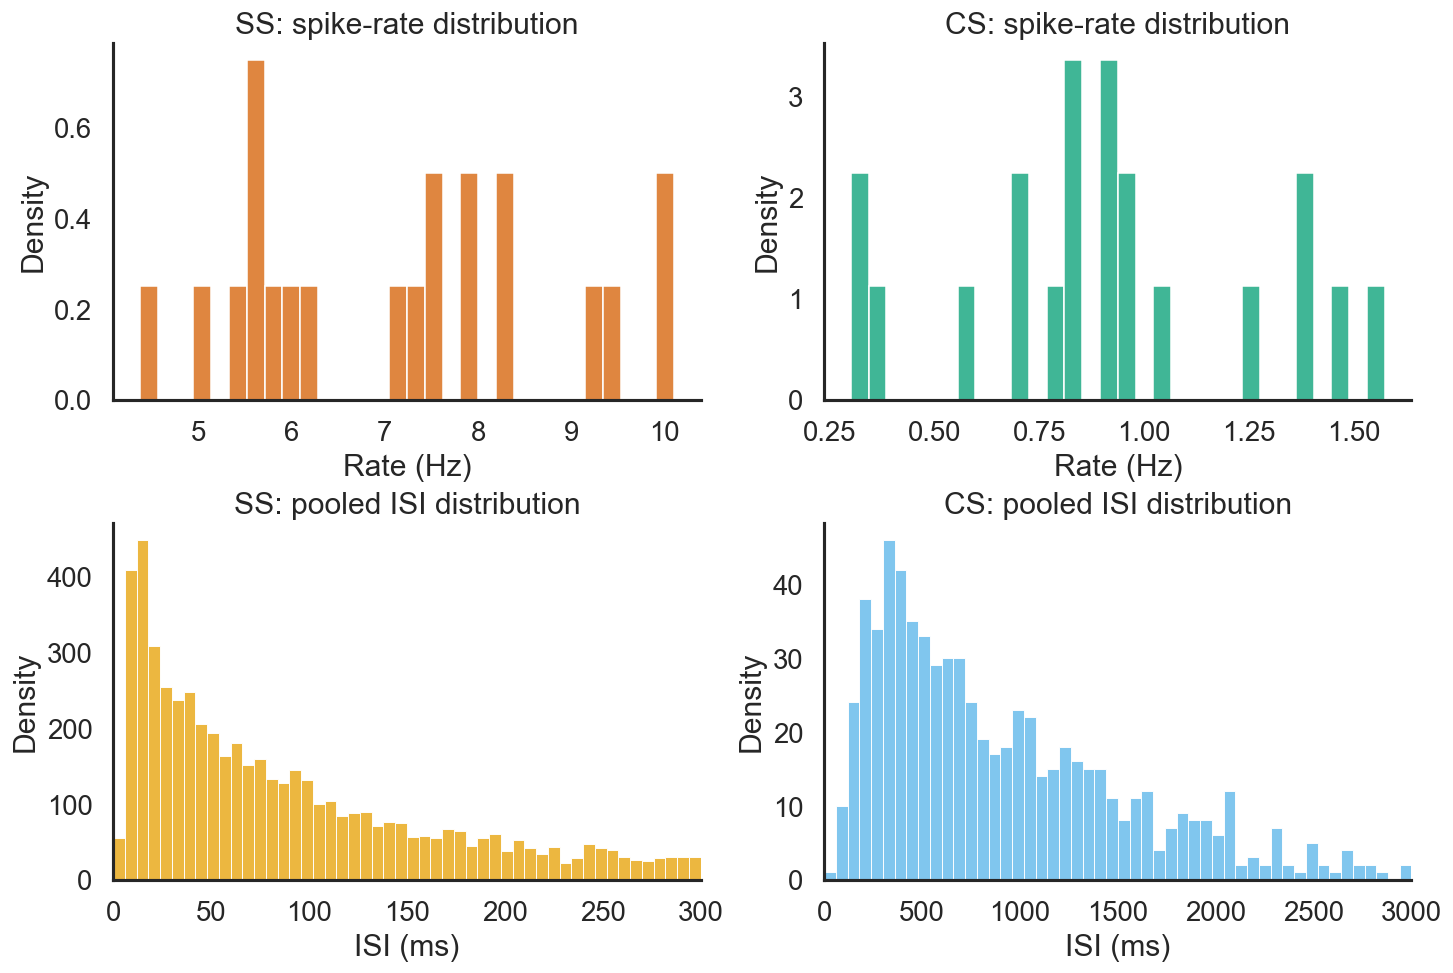

In [6]:
# Spike statistics before synchronization (pooled + per-cell, configurable by SPIKE_STATS_CONFIG).
def _compute_trace_spike_stats(spike_times, duration_s, min_spikes_for_isi=2):
    st = np.sort(np.asarray(spike_times, dtype=float))
    st = st[np.isfinite(st)]
    n_spikes = int(st.size)
    rate_hz = float(n_spikes / duration_s) if duration_s > 0 else np.nan

    if n_spikes >= int(min_spikes_for_isi):
        isi = np.diff(st)
        isi = isi[np.isfinite(isi) & (isi > 0)]
    else:
        isi = np.array([], dtype=float)

    if isi.size > 0:
        isi_mean = float(np.mean(isi))
        isi_median = float(np.median(isi))
        isi_cv = float(np.std(isi, ddof=1) / (isi_mean + 1e-12)) if isi.size > 1 else np.nan
    else:
        isi_mean = np.nan
        isi_median = np.nan
        isi_cv = np.nan

    return {
        'n_spikes': n_spikes,
        'rate_hz': rate_hz,
        'isi_mean_ms': isi_mean,
        'isi_median_ms': isi_median,
        'isi_cv': isi_cv,
        'n_isi': int(isi.size),
        'isi_values_ms': isi,
    }

def _build_spike_stats_tables(sessions_local, spike_types=('SS', 'CS'), min_spikes_for_isi=2):
    rows = []
    isi_pool = {stype: [] for stype in spike_types}

    for s in sessions_local:
        duration_s = float(s['duration_ms']) / 1000.0
        for stype in spike_types:
            spikes_by_cell = s['spike_times_ss'] if stype == 'SS' else s['spike_times_cs']
            for i, st in enumerate(spikes_by_cell):
                stats = _compute_trace_spike_stats(st, duration_s, min_spikes_for_isi=min_spikes_for_isi)
                rows.append({
                    'session': s['session_name'],
                    'spike_type': stype,
                    'cell': s['cell_names'][i],
                    'cell_idx': int(i),
                    'duration_s': duration_s,
                    'n_spikes': stats['n_spikes'],
                    'rate_hz': stats['rate_hz'],
                    'isi_mean_ms': stats['isi_mean_ms'],
                    'isi_median_ms': stats['isi_median_ms'],
                    'isi_cv': stats['isi_cv'],
                    'n_isi': stats['n_isi'],
                })
                if stats['n_isi'] > 0:
                    isi_pool[stype].append(stats['isi_values_ms'])

    detail_df = pd.DataFrame(rows)
    for stype in isi_pool:
        isi_pool[stype] = np.concatenate(isi_pool[stype]) if len(isi_pool[stype]) else np.array([], dtype=float)
    return detail_df, isi_pool

if SPIKE_STATS_CONFIG.get('enabled', True):
    spike_types = [str(x).upper() for x in SPIKE_STATS_CONFIG.get('spike_types', ['SS', 'CS'])]
    spike_types = [x for x in spike_types if x in {'SS', 'CS'}]
    if not spike_types:
        spike_types = ['SS', 'CS']

    min_spikes_for_isi = int(SPIKE_STATS_CONFIG.get('min_spikes_for_isi', 2))
    detail_df, pooled_isi = _build_spike_stats_tables(
        sessions,
        spike_types=tuple(spike_types),
        min_spikes_for_isi=min_spikes_for_isi,
    )

    print('Spike statistics section is enabled (before synchrony).')

    if SPIKE_STATS_CONFIG.get('show_pooled_summary', True):
        pooled_summary = (detail_df.groupby('spike_type', as_index=False)
                          .agg(n_sessions=('session', 'nunique'),
                               n_cells_x_sessions=('cell', 'count'),
                               total_spikes=('n_spikes', 'sum'),
                               rate_hz_mean=('rate_hz', 'mean'),
                               rate_hz_median=('rate_hz', 'median'),
                               isi_mean_ms_mean=('isi_mean_ms', 'mean'),
                               isi_median_ms_median=('isi_median_ms', 'median'),
                               isi_cv_mean=('isi_cv', 'mean'),
                               traces_with_isi=('n_isi', lambda x: int(np.sum(np.asarray(x) > 0)))))
        print('\nPooled spike statistics by spike type:')
        display(pooled_summary)

    if SPIKE_STATS_CONFIG.get('show_cell_summary_table', True):
        cell_summary = (detail_df.groupby(['spike_type', 'cell', 'cell_idx'], as_index=False)
                        .agg(n_sessions=('session', 'nunique'),
                             mean_n_spikes=('n_spikes', 'mean'),
                             mean_rate_hz=('rate_hz', 'mean'),
                             mean_isi_ms=('isi_mean_ms', 'mean'),
                             median_isi_ms=('isi_median_ms', 'median'),
                             mean_isi_cv=('isi_cv', 'mean')))
        max_rows_cell = int(SPIKE_STATS_CONFIG.get('max_rows_cell_summary_table', 30))
        print('\nPer-cell pooled spike statistics (across sessions):')
        display(cell_summary.head(max_rows_cell))

    if SPIKE_STATS_CONFIG.get('show_session_cell_table', False):
        max_rows_detail = int(SPIKE_STATS_CONFIG.get('max_rows_session_cell_table', 30))
        print('\nDetailed per-session/per-cell spike statistics:')
        display(detail_df.head(max_rows_detail))

    if SPIKE_STATS_CONFIG.get('show_plots', True):
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
        for col_idx, stype in enumerate(['SS', 'CS']):
            if stype not in spike_types:
                axes[0, col_idx].axis('off')
                axes[1, col_idx].axis('off')
                continue

            sub = detail_df[detail_df['spike_type'] == stype]

            ax_rate = axes[0, col_idx]
            if len(sub) > 0 and np.isfinite(sub['rate_hz']).any():
                sns.histplot(sub['rate_hz'].dropna(), bins=30, stat='density', ax=ax_rate, color=('#D55E00' if stype == 'SS' else '#009E73'))
            else:
                ax_rate.text(0.5, 0.5, f'No valid {stype} rate values', ha='center', va='center', transform=ax_rate.transAxes)
            ax_rate.set_title(f'{stype}: spike-rate distribution')
            ax_rate.set_xlabel('Rate (Hz)')
            ax_rate.set_ylabel('Density')
            ax_rate.grid(False)

            ax_isi = axes[1, col_idx]
            isi_vals = pooled_isi.get(stype, np.array([], dtype=float))
            if isi_vals.size > 0:
                if stype == 'SS':
                    _isi_bins = int(SPIKE_STATS_CONFIG.get('ss_isi_n_bins', 100))
                    _isi_max = float(SPIKE_STATS_CONFIG.get('ss_isi_plot_max_ms', 200.0))
                else:
                    _isi_bins = int(SPIKE_STATS_CONFIG.get('cs_isi_n_bins', 40))
                    _isi_max = float(SPIKE_STATS_CONFIG.get('cs_isi_plot_max_ms', 2000.0))
                _isi_edges = np.linspace(0, _isi_max, _isi_bins + 1)
                sns.histplot(isi_vals, bins=_isi_edges, stat='count', ax=ax_isi, color=('#E69F00' if stype == 'SS' else '#56B4E9'))
                ax_isi.set_xlim(0, _isi_max)
            else:
                ax_isi.text(0.5, 0.5, f'No valid {stype} ISI values', ha='center', va='center', transform=ax_isi.transAxes)
            ax_isi.set_title(f'{stype}: pooled ISI distribution')
            ax_isi.set_xlabel('ISI (ms)')
            ax_isi.set_ylabel('Density')
            ax_isi.grid(False)

        _save_fig_svg(fig, 'spike_stats_rate_isi')
        plt.show()
else:
    print("Spike statistics section is hidden. Set SPIKE_STATS_CONFIG['enabled'] = True to show it.")

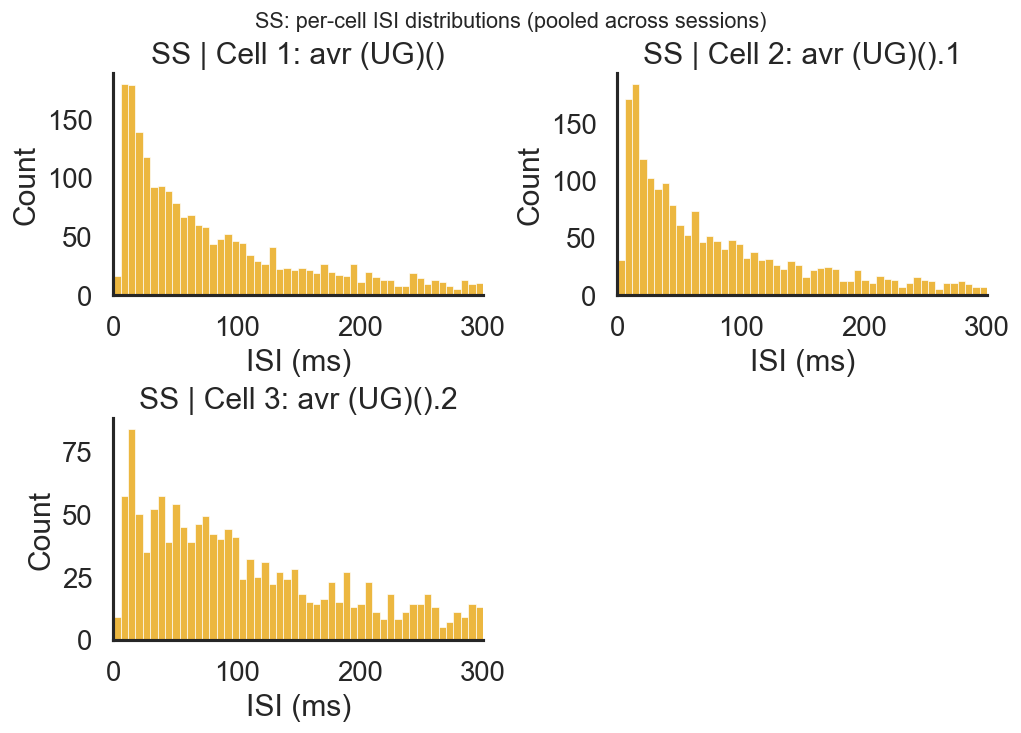

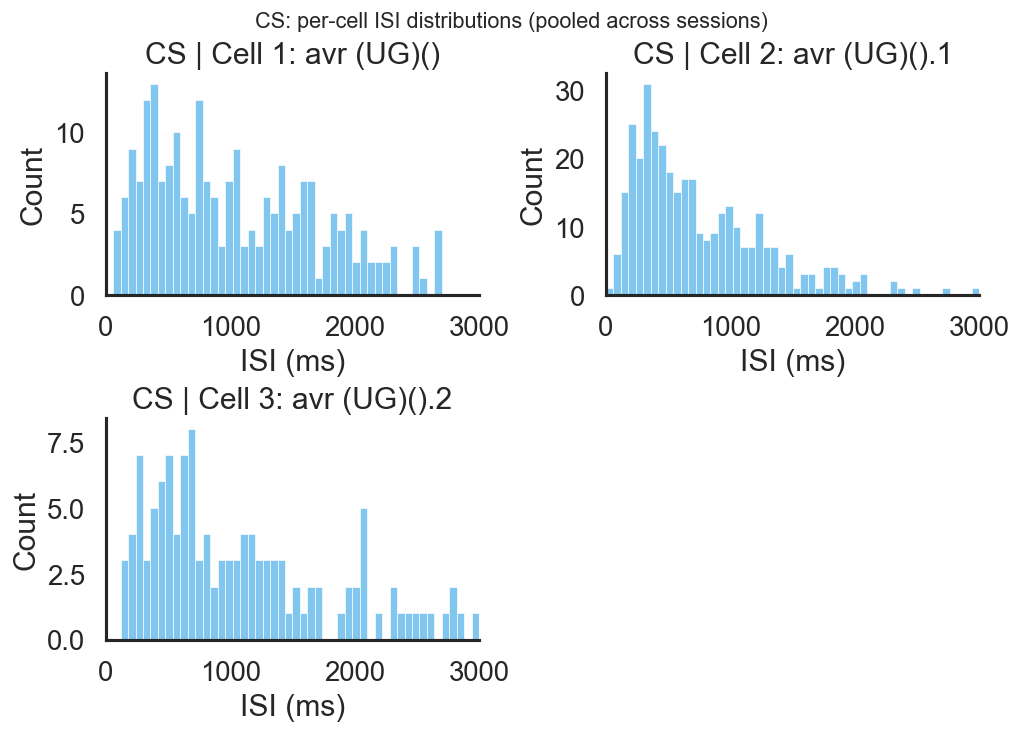

In [7]:
min_spikes_for_isi = int(SPIKE_STATS_CONFIG.get('min_spikes_for_isi', 2))
ss_isi_bins = int(SPIKE_STATS_CONFIG.get('ss_isi_n_bins', 100))
cs_isi_bins = int(SPIKE_STATS_CONFIG.get('cs_isi_n_bins', 40))
ss_isi_max = float(SPIKE_STATS_CONFIG.get('ss_isi_plot_max_ms', 200.0))
cs_isi_max = float(SPIKE_STATS_CONFIG.get('cs_isi_plot_max_ms', 2000.0))

for stype in spike_types:
    per_cell_isi = {}
    for i, cname in enumerate(cell_names):
        chunks = []
        for s in sessions:
            spikes = s['spike_times_ss'][i] if stype == 'SS' else s['spike_times_cs'][i]
            spikes = np.sort(np.asarray(spikes, dtype=float))
            spikes = spikes[np.isfinite(spikes)]
            if spikes.size >= min_spikes_for_isi:
                isi = np.diff(spikes)
                isi = isi[np.isfinite(isi) & (isi > 0)]
                if isi.size > 0:
                    chunks.append(isi)
        if chunks:
            per_cell_isi[(i, str(cname))] = np.concatenate(chunks)

    if not per_cell_isi:
        print(f'No valid {stype} ISI values for per-cell ISI plots.')
        continue

    keys = sorted(per_cell_isi.keys(), key=lambda x: x[0])
    n = len(keys)
    ncols = min(n, max(1, int(np.ceil(np.sqrt(n)))))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for idx, (cell_idx, cell_name) in enumerate(keys):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]
        vals = np.asarray(per_cell_isi[(cell_idx, cell_name)], dtype=float)
        vals = vals[np.isfinite(vals) & (vals > 0)]
        if vals.size > 0:
            _bins = ss_isi_bins if stype == 'SS' else cs_isi_bins
            _max = ss_isi_max if stype == 'SS' else cs_isi_max
            _edges = np.linspace(0, _max, _bins + 1)
            sns.histplot(vals, bins=_edges, stat='count', ax=ax,
                         color=('#E69F00' if stype == 'SS' else '#56B4E9'))
            ax.set_xlim(0, _max)
        else:
            ax.text(0.5, 0.5, 'No ISI values', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{stype} | Cell {cell_idx + 1}: {cell_name}')
        ax.set_xlabel('ISI (ms)')
        ax.set_ylabel('Count')
        ax.grid(False)

    for idx in range(n, nrows * ncols):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].axis('off')

    fig.suptitle(f'{stype}: per-cell ISI distributions (pooled across sessions)', fontsize=13)
    _save_fig_svg(fig, f'per_cell_ISI_{stype}')
    plt.show()

In [8]:
def build_binned_counts(spike_times_by_cell, t_start, t_end, bin_ms):
    edges = np.arange(t_start, t_end + bin_ms, bin_ms)
    if len(edges) < 3:
        edges = np.array([t_start, t_end])
    counts = []
    for st in spike_times_by_cell:
        c, _ = np.histogram(st, bins=edges)
        counts.append(c.astype(float))
    return np.asarray(counts), edges

def corr_matrix_from_counts(counts):
    n = counts.shape[0]
    out = np.eye(n, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            a, b = counts[i], counts[j]
            if np.std(a) == 0 or np.std(b) == 0:
                r = 0.0
            else:
                r = float(np.corrcoef(a, b)[0, 1])
            out[i, j] = out[j, i] = r
    return out

def pair_ccg_probability(times_ref, times_target, bin_ms, max_lag_ms):
    bins = np.arange(-max_lag_ms, max_lag_ms + bin_ms, bin_ms)
    if len(times_ref) == 0 or len(times_target) == 0:
        centers = bins[:-1] + bin_ms / 2
        return centers, np.zeros_like(centers, dtype=float)

    diffs = []
    for t in times_ref:
        i0 = np.searchsorted(times_target, t - max_lag_ms)
        i1 = np.searchsorted(times_target, t + max_lag_ms)
        local = times_target[i0:i1]
        if len(local):
            diffs.extend(local - t)

    counts, edges = np.histogram(diffs, bins=bins)
    prob = counts.astype(float) / max(len(times_ref), 1)
    centers = edges[:-1] + bin_ms / 2
    return centers, prob

def _safe_scalar(x):
    if np.isscalar(x):
        try:
            return float(x)
        except Exception:
            return np.nan
    arr = np.asarray(x).reshape(-1)
    if arr.size == 0:
        return np.nan
    try:
        return float(arr[0])
    except Exception:
        return np.nan

def _gaussian_smooth(y, sigma_bins=1.0):
    sigma_bins = float(sigma_bins)
    if sigma_bins <= 0:
        return y
    radius = max(3, int(np.ceil(4 * sigma_bins)))
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma_bins) ** 2)
    kernel /= np.sum(kernel)
    return np.convolve(y, kernel, mode='same')

def _plot_grid_panels(panel_specs, ncols=3, fig_w=15, row_h=3.0, suptitle=None):
    n = len(panel_specs)
    if n == 0:
        return

    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, row_h * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for k, spec in enumerate(panel_specs):
        r = k // ncols
        c = k % ncols
        ax = axes[r, c]
        ax.plot(spec['x'], spec['y'], color=spec['line_color'], lw=2.2)
        ax.fill_between(spec['x'], spec['y'], 0, color=spec['fill_color'], alpha=spec['alpha'])
        ax.axvline(0, color='lightgray', ls='--', lw=1)
        ax.set_title(spec['title'], fontsize=11)
        if spec.get('ylabel'):
            ax.set_ylabel(spec['ylabel'])
        if spec.get('xlabel'):
            ax.set_xlabel(spec['xlabel'])
        if spec.get('xlim') is not None:
            ax.set_xlim(*spec['xlim'])

    # hide unused axes
    for k in range(n, nrows * ncols):
        r = k // ncols
        c = k % ncols
        axes[r, c].axis('off')

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)


def compute_prob_ccg(spikes_ref, spikes_target, bin_ms=1.0, window_ms=50.0, sigma_bins=1.2, is_acg=False):
    bins = np.arange(-window_ms, window_ms + bin_ms, bin_ms)
    if len(spikes_ref) == 0 or len(spikes_target) == 0:
        centers = bins[:-1] + bin_ms / 2
        return centers, np.zeros_like(centers, dtype=float)

    all_lags = []
    for t in spikes_ref:
        i0 = np.searchsorted(spikes_target, t - window_ms)
        i1 = np.searchsorted(spikes_target, t + window_ms)
        local = spikes_target[i0:i1] - t
        if is_acg:
            # remove self-spike at ~0 lag for refractory dip visualization
            local = local[np.abs(local) > (bin_ms * 0.5)]
        if len(local):
            all_lags.extend(local.tolist())

    counts, edges = np.histogram(all_lags, bins=bins)
    prob = counts.astype(float) / max(len(spikes_ref), 1)
    prob = _gaussian_smooth(prob, sigma_bins=sigma_bins)
    centers = edges[:-1] + bin_ms / 2
    return centers, prob

def _pick_cells(session, cfg):
    n = session['n_cells']
    if n < 2:
        return [0] if n == 1 else []

    req = cfg.get('cell_indices', None)
    max_cells = int(cfg.get('max_cells', 4))
    max_cells = min(max_cells, n)
    max_cells = max(2, max_cells)

    if req is None:
        return list(range(max_cells))

    valid = [int(i) for i in req if 0 <= int(i) < n]
    if len(valid) < 2:
        return list(range(max_cells))
    return valid

def plot_ccg_style_panel(session, cfg):
    idx = _pick_cells(session, cfg)
    if len(idx) < 2:
        print(f"Skipping CCG style panel for {session['session_name']}: need at least 2 valid cells")
        return

    ss = session['spike_times_ss']
    cs = session['spike_times_cs']
    sigma = float(cfg.get('smooth_sigma_bins', 1.2))

    # 1) SS-ACG for each selected cell
    acg_specs = []
    for local_k, ci in enumerate(idx):
        lag, prob = compute_prob_ccg(
            ss[ci], ss[ci],
            bin_ms=cfg['ss_acg_bin_ms'],
            window_ms=cfg['ss_acg_window_ms'],
            sigma_bins=sigma,
            is_acg=True,
        )
        acg_specs.append({
            'x': lag,
            'y': prob,
            'title': f'Cell {local_k + 1} SS-ACG',
            'line_color': '#3AA657',
            'fill_color': '#3AA657',
            'alpha': 0.22,
            'ylabel': 'ACG Prob.' if local_k == 0 else None,
            'xlabel': None,
            'xlim': (-cfg['ss_acg_window_ms'], cfg['ss_acg_window_ms']),
        })
    _plot_grid_panels(
        acg_specs,
        ncols=min(4, len(acg_specs)),
        fig_w=max(11, 3.8 * min(4, len(acg_specs))),
        row_h=2.7,
        suptitle=f"{session['session_name']} | SS-ACG"
    )

    # generate pair list once
    pairs = []
    for a in range(len(idx)):
        for b in range(a + 1, len(idx)):
            pairs.append((a + 1, b + 1, idx[a], idx[b]))

    # 2) SS-CCG for all pairs
    ss_specs = []
    for a_label, b_label, i, j in pairs:
        lag, prob = compute_prob_ccg(
            ss[i], ss[j],
            bin_ms=cfg['ss_ccg_bin_ms'],
            window_ms=cfg['ss_ccg_window_ms'],
            sigma_bins=sigma,
            is_acg=False,
        )
        ss_specs.append({
            'x': lag,
            'y': prob,
            'title': f'SS-CCG: Cell {a_label} vs {b_label}',
            'line_color': '#2C2C2C',
            'fill_color': '#2C2C2C',
            'alpha': 0.18,
            'ylabel': 'SS Coinc. Prob.' if len(ss_specs) == 0 else None,
            'xlabel': 'Lag (ms)',
            'xlim': (-cfg['ss_ccg_window_ms'], cfg['ss_ccg_window_ms']),
        })
    _plot_grid_panels(
        ss_specs,
        ncols=min(3, max(1, len(ss_specs))),
        fig_w=max(11, 4.4 * min(3, max(1, len(ss_specs)))),
        row_h=2.9,
        suptitle=f"{session['session_name']} | SS-CCG"
    )

    # 3) CS-CCG for all pairs
    cs_specs = []
    for a_label, b_label, i, j in pairs:
        lag, prob = compute_prob_ccg(
            cs[i], cs[j],
            bin_ms=cfg['cs_ccg_bin_ms'],
            window_ms=cfg['cs_ccg_window_ms'],
            sigma_bins=sigma,
            is_acg=False,
        )
        cs_specs.append({
            'x': lag,
            'y': prob,
            'title': f'CS-CCG: Cell {a_label} vs {b_label}',
            'line_color': '#23A98C',
            'fill_color': '#23A98C',
            'alpha': 0.20,
            'ylabel': 'CS Coinc. Prob.' if len(cs_specs) == 0 else None,
            'xlabel': 'Lag (ms)',
            'xlim': (-cfg['cs_ccg_window_ms'], cfg['cs_ccg_window_ms']),
        })
    _plot_grid_panels(
        cs_specs,
        ncols=min(3, max(1, len(cs_specs))),
        fig_w=max(11, 4.4 * min(3, max(1, len(cs_specs)))),
        row_h=2.9,
        suptitle=f"{session['session_name']} | CS-CCG"
    )

def shuffle_significance(times_a, times_b, t_start, t_end, bin_ms, n_shuffles=500):
    duration = t_end - t_start
    if duration <= 0 or len(times_a) < 5 or len(times_b) < 5:
        return np.nan, np.nan, np.nan

    edges = np.arange(t_start, t_end + bin_ms, bin_ms)
    b1, _ = np.histogram(times_a, bins=edges)
    if np.std(b1) == 0:
        return np.nan, np.nan, np.nan

    def _corr(x, y):
        if np.std(x) == 0 or np.std(y) == 0:
            return 0.0
        return float(np.corrcoef(x, y)[0, 1])

    b2, _ = np.histogram(times_b, bins=edges)
    real_r = _corr(b1, b2)

    shuffled = []
    rel = times_b - t_start
    for _ in range(n_shuffles):
        shift = np.random.uniform(0.1 * duration, 0.9 * duration)
        shifted = (rel + shift) % duration + t_start
        bs, _ = np.histogram(shifted, bins=edges)
        shuffled.append(_corr(b1, bs))

    shuffled = np.asarray(shuffled, dtype=float)
    p_two_sided = (np.sum(np.abs(shuffled) >= abs(real_r)) + 1.0) / (len(shuffled) + 1.0)
    z = (real_r - np.mean(shuffled)) / (np.std(shuffled) + 1e-9)
    return _safe_scalar(real_r), _safe_scalar(p_two_sided), _safe_scalar(z)

def compute_session_sync(session, spike_type='SS', cfg=None):
    cfg = cfg or SYNC_CONFIG
    spikes = session['spike_times_ss'] if spike_type.upper() == 'SS' else session['spike_times_cs']
    bin_ms = cfg['ss_bin_ms'] if spike_type.upper() == 'SS' else cfg['cs_bin_ms']

    t0 = float(session['time_ms'][0])
    t1 = float(session['time_ms'][-1])
    counts, edges = build_binned_counts(spikes, t0, t1, bin_ms)
    corr_mat = corr_matrix_from_counts(counts)

    pair_rows = []
    for i, j in combinations(range(session['n_cells']), 2):
        real_r, p_val, z_score = shuffle_significance(
            spikes[i], spikes[j], t0, t1, bin_ms=bin_ms, n_shuffles=cfg['shuffle_n']
        )
        pair_rows.append({
            'session': session['session_name'],
            'spike_type': spike_type.upper(),
            'cell_i': session['cell_names'][i],
            'cell_j': session['cell_names'][j],
            'i': i,
            'j': j,
            'r': _safe_scalar(real_r),
            'p': _safe_scalar(p_val),
            'z': _safe_scalar(z_score),
        })

    return {
        'counts': counts,
        'edges': edges,
        'corr': corr_mat,
        'pair_df': pd.DataFrame(pair_rows),
    }

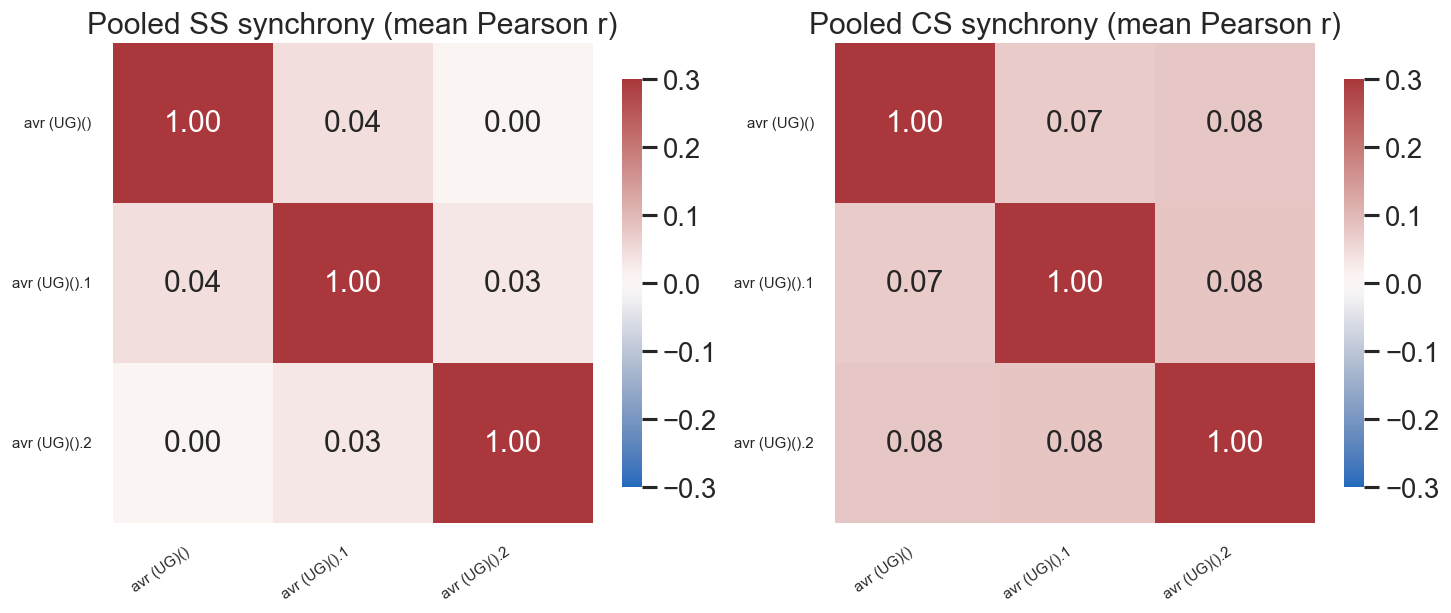

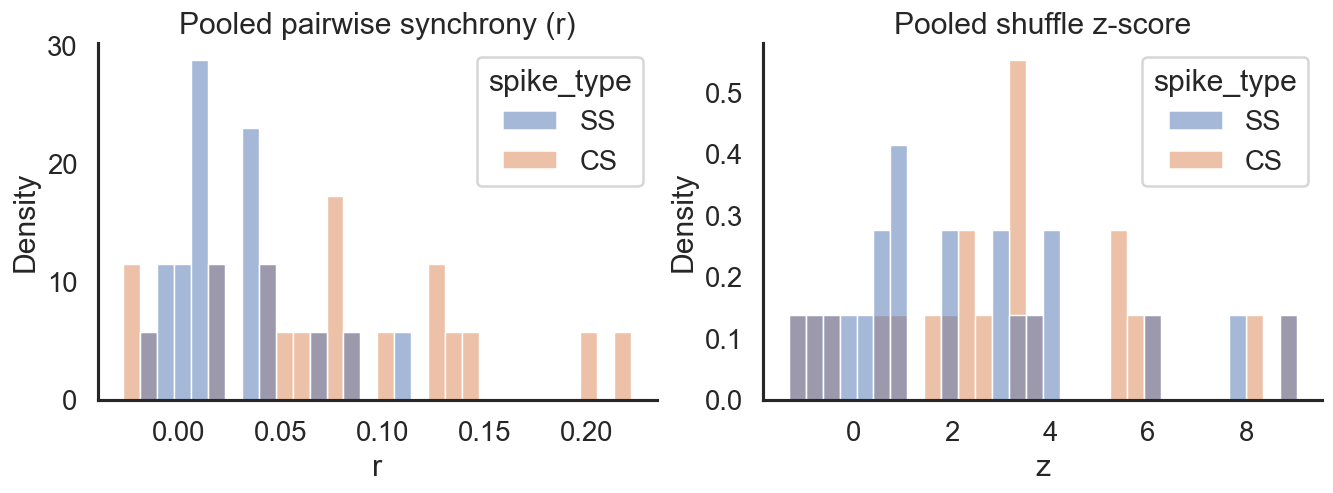

SS interaction summary across loaded sessions (Cell1-Cell2 and Cell1-Cell3):


,cell_i,cell_j,n_sessions,mean_r,median_r,mean_z,frac_p_lt_0_05
0,avr (UG)(),avr (UG)().1,7,0.043357,0.03875,3.915872,0.714286
1,avr (UG)(),avr (UG)().2,7,0.004932,0.00353,0.426466,0.142857


,session,spike_type,cell_i,cell_j,i,j,r,p,z
0,puff_10,SS,avr (UG)(),avr (UG)().1,0,1,0.034782,0.003992,3.154744
1,puff_10,SS,avr (UG)(),avr (UG)().2,0,2,0.003530,0.720559,0.326945
2,puff_10,SS,avr (UG)().1,avr (UG)().2,1,2,0.006853,0.592814,0.490296
3,puff_10,CS,avr (UG)(),avr (UG)().1,0,1,0.098835,0.005988,3.780813
4,puff_10,CS,avr (UG)(),avr (UG)().2,0,2,0.130252,0.001996,6.021968


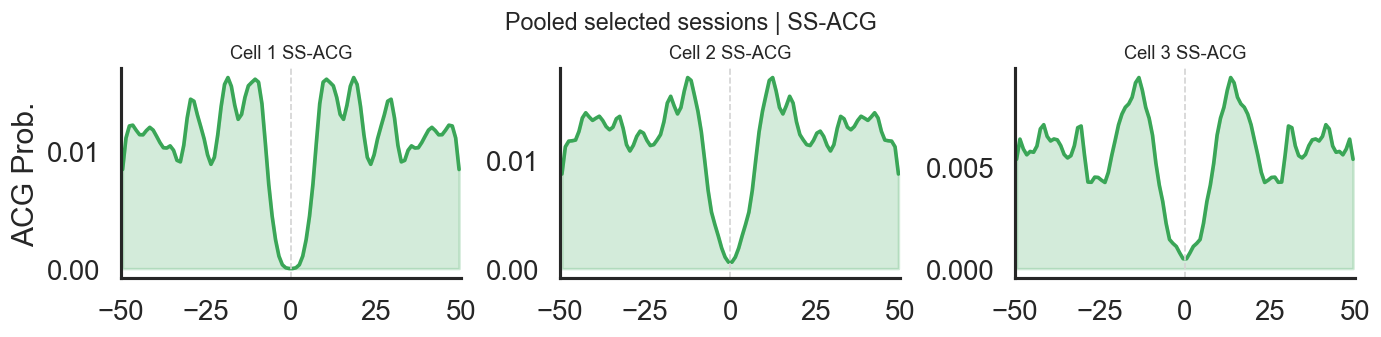

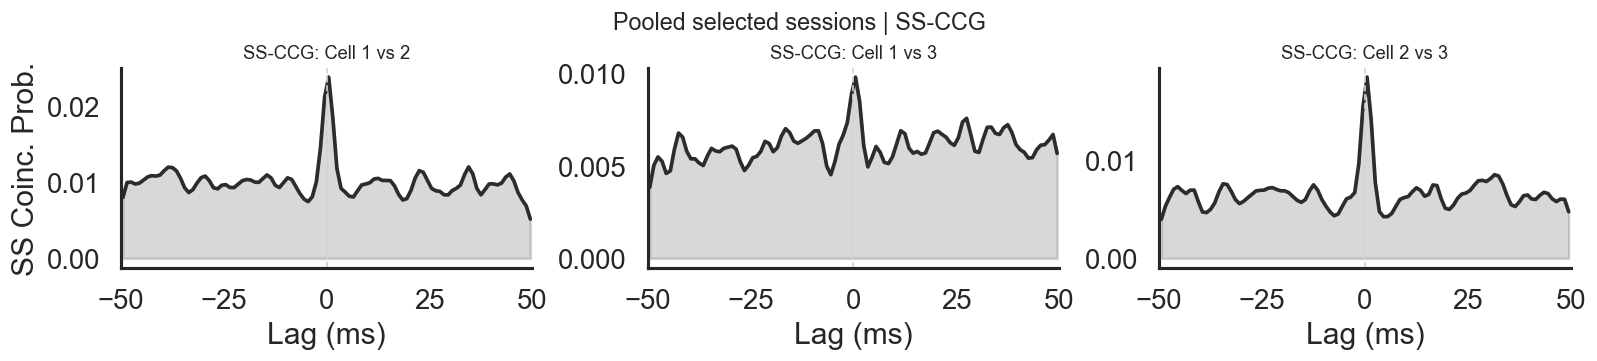

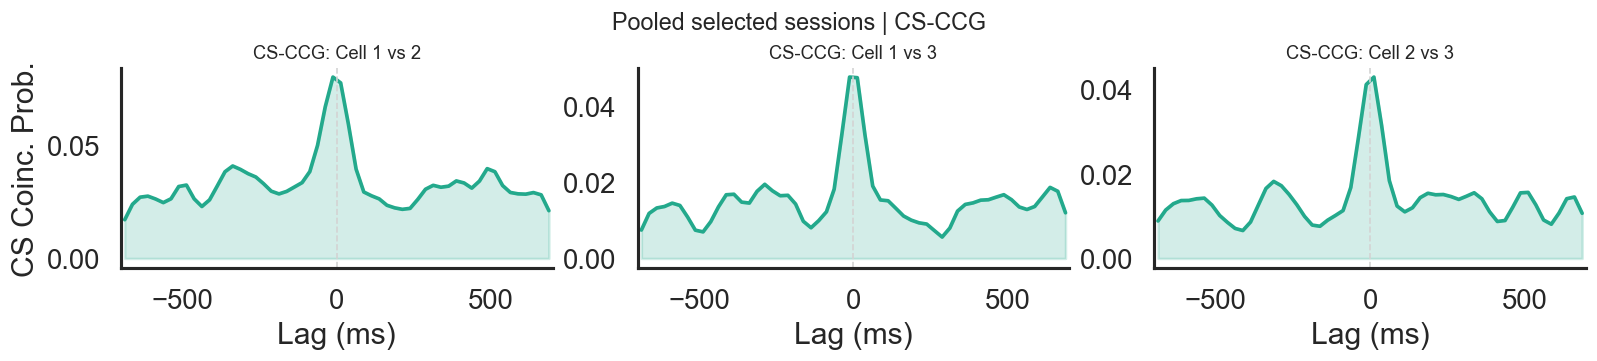

In [9]:
sync_results = {}
all_pair_stats = []

selected_names = SYNC_VIEW.get('session_names', None)
if selected_names is None:
    selected_set = {s['session_name'] for s in sessions}
else:
    selected_set = set(selected_names)

sessions_for_sync = [s for s in sessions if s['session_name'] in selected_set]
if not sessions_for_sync:
    raise ValueError('No sessions matched SYNC_VIEW["session_names"].')

mode = str(SYNC_VIEW.get('mode', 'pooled')).strip().lower()
if mode not in {'pooled', 'per-session', 'both'}:
    raise ValueError("SYNC_VIEW['mode'] must be one of: 'pooled', 'per-session', 'both'")

exclude_event_mod_window = bool(SYNC_EXCLUDE_EVENT_MOD_WINDOW.get('enabled', False))
sync_suffix = ' (event-mod period excluded)' if exclude_event_mod_window else ''

def _remove_event_window_spikes(spike_times, event_time_ms, window_ms):
    w0, w1 = float(window_ms[0]), float(window_ms[1])
    t0 = event_time_ms + w0
    t1 = event_time_ms + w1
    st = np.asarray(spike_times, dtype=float)
    return st[(st < t0) | (st >= t1)]

def _prep_sync_session(session):
    if not exclude_event_mod_window:
        return session

    # Always use response windows from EVENT_CONFIG when exclusion is enabled.
    ss_window = EVENT_CONFIG['ss_rate_response_ms']
    cs_window = EVENT_CONFIG['cs_rate_response_ms']

    out = dict(session)
    out['spike_times_ss'] = [
        _remove_event_window_spikes(st, EVENT_CONFIG['event_time_ms'], ss_window)
        for st in session['spike_times_ss']
    ]
    out['spike_times_cs'] = [
        _remove_event_window_spikes(st, EVENT_CONFIG['event_time_ms'], cs_window)
        for st in session['spike_times_cs']
    ]
    return out

if exclude_event_mod_window:
    print('Synchrony uses spikes with event-modulated response windows removed:')
    print(f"  SS removed window: {EVENT_CONFIG['ss_rate_response_ms']} ms relative to event")
    print(f"  CS removed window: {EVENT_CONFIG['cs_rate_response_ms']} ms relative to event")

# Single-cell guard: no pairwise synchrony can be computed.
if n_cells < 2:
    print('Single-cell dataset detected (n_cells=1). Skipping pairwise synchrony and CCG sections.')
    pair_stats_df = pd.DataFrame(columns=['session', 'spike_type', 'cell_i', 'cell_j', 'i', 'j', 'r', 'p', 'z'])

    # Keep simple self-correlation heatmaps so pipeline still has synchrony context.
    if mode in {'pooled', 'both'} and SYNC_VIEW.get('show_pooled_heatmaps', True):
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
        for ax, stype in zip(axes, ['SS', 'CS']):
            mat = np.array([[1.0]])
            sns.heatmap(mat, vmin=-1, vmax=1, center=0, cmap='vlag', square=True,
                        xticklabels=cell_names, yticklabels=cell_names, annot=True, fmt='.2f', ax=ax)
            ax.set_title(f'Pooled {stype} synchrony (single cell){sync_suffix}')
        plt.show()

    if mode in {'per-session', 'both'}:
        for s in sessions_for_sync:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
            for ax, stype in zip(axes, ['SS', 'CS']):
                mat = np.array([[1.0]])
                sns.heatmap(mat, vmin=-1, vmax=1, center=0, cmap='vlag', square=True,
                            xticklabels=cell_names, yticklabels=cell_names, annot=True, fmt='.2f', ax=ax)
                ax.set_title(f"{s['session_name']}: {stype} synchrony (single cell){sync_suffix}")
            plt.show()

    display(pair_stats_df.head())

else:
    for s in sessions_for_sync:
        s_sync = _prep_sync_session(s)
        ss_res = compute_session_sync(s_sync, 'SS', SYNC_CONFIG)
        cs_res = compute_session_sync(s_sync, 'CS', SYNC_CONFIG)
        sync_results[s['session_name']] = {'SS': ss_res, 'CS': cs_res}
        all_pair_stats.append(ss_res['pair_df'])
        all_pair_stats.append(cs_res['pair_df'])

    pair_stats_df = pd.concat(all_pair_stats, ignore_index=True) if all_pair_stats else pd.DataFrame()
    if not pair_stats_df.empty:
        for col in ['r', 'p', 'z']:
            pair_stats_df[col] = pair_stats_df[col].apply(_safe_scalar)
        pair_stats_df['r'] = pd.to_numeric(pair_stats_df['r'], errors='coerce')
        pair_stats_df['p'] = pd.to_numeric(pair_stats_df['p'], errors='coerce')
        pair_stats_df['z'] = pd.to_numeric(pair_stats_df['z'], errors='coerce')

    # Pooled correlation heatmaps (all selected sessions)
    if mode in {'pooled', 'both'} and SYNC_VIEW.get('show_pooled_heatmaps', True):
        ss_stack = np.stack([sync_results[s['session_name']]['SS']['corr'] for s in sessions_for_sync], axis=0)
        cs_stack = np.stack([sync_results[s['session_name']]['CS']['corr'] for s in sessions_for_sync], axis=0)
        pooled_ss = np.nanmean(ss_stack, axis=0)
        pooled_cs = np.nanmean(cs_stack, axis=0)

        fig_w = max(12.0, 1.2 * n_cells + 6.0)
        fig_h = max(5.0, 0.95 * n_cells + 1.0)
        fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)

        for ax, mat, stype in zip(axes, [pooled_ss, pooled_cs], ['SS', 'CS']):
            sns.heatmap(
                mat,
                vmin=-1,
                vmax=1,
                center=0,
                cmap='vlag',
                square=True,
                xticklabels=cell_names,
                yticklabels=cell_names,
                annot=(n_cells <= 10),
                fmt='.2f',
                cbar_kws={'shrink': 0.85},
                ax=ax,
            )
            ax.set_title(f'Pooled {stype} synchrony (mean Pearson r){sync_suffix}')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

        plt.show()

    if mode in {'per-session', 'both'}:
        for s in sessions_for_sync:
            name = s['session_name']

            fig_w = max(12.0, 1.2 * n_cells + 6.0)
            fig_h = max(5.0, 0.95 * n_cells + 1.0)
            fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)
            for ax, stype in zip(axes, ['SS', 'CS']):
                mat = sync_results[name][stype]['corr']
                sns.heatmap(
                    mat,
                    vmin=-1,
                    vmax=1,
                    center=0,
                    cmap='vlag',
                    square=True,
                    xticklabels=cell_names,
                    yticklabels=cell_names,
                    annot=(n_cells <= 10),
                    fmt='.2f',
                    cbar_kws={'shrink': 0.85},
                    ax=ax,
                )
                ax.set_title(f'{name}: {stype} synchrony (Pearson r){sync_suffix}')
                ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
                ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
            plt.show()

            # Top-N CCG pairs by |r|
            for stype in ['SS', 'CS']:
                p = sync_results[name][stype]['pair_df'].copy()
                p['r'] = p['r'].apply(_safe_scalar)
                p = p.dropna(subset=['r'])
                if p.empty:
                    continue
                p['abs_r'] = p['r'].abs()
                top = p.sort_values('abs_r', ascending=False).head(SYNC_CONFIG['ccg_pairs_top_n'])

                n_top = len(top)
                fig_h = max(3.0 * n_top, 4.0)
                fig, axs = plt.subplots(n_top, 1, figsize=(11, fig_h), squeeze=False, constrained_layout=True)
                for row_idx, row in enumerate(top.itertuples(index=False)):
                    i, j = int(row.i), int(row.j)
                    spikes = s['spike_times_ss'] if stype == 'SS' else s['spike_times_cs']
                    bin_ms = SYNC_CONFIG['ss_bin_ms'] if stype == 'SS' else SYNC_CONFIG['cs_bin_ms']
                    lag_ms = SYNC_CONFIG['ss_max_lag_ms'] if stype == 'SS' else SYNC_CONFIG['cs_max_lag_ms']
                    lag, prob = pair_ccg_probability(spikes[i], spikes[j], bin_ms=bin_ms, max_lag_ms=lag_ms)

                    ax = axs[row_idx, 0]
                    ax.plot(lag, prob, color='#2F4B7C', lw=2)
                    ax.axvline(0, color='k', ls='--', alpha=0.5)
                    ax.set_title(
                        f'{name} | {stype} | {row.cell_i} vs {row.cell_j} | '
                        f'r={row.r:.3f}, p={_safe_scalar(row.p):.3g}, z={_safe_scalar(row.z):.2f}',
                        fontsize=10,
                    )
                    ax.set_xlabel('Lag (ms)')
                    ax.set_ylabel('P(target | reference)')
                plt.show()

    if mode in {'pooled', 'both'} and not pair_stats_df.empty and SYNC_VIEW.get('show_pooled_distributions', True):
        fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

        r_df = pair_stats_df.dropna(subset=['r'])
        if not r_df.empty:
            sns.histplot(data=r_df, x='r', hue='spike_type', bins=30, stat='density', common_norm=False, ax=axes[0])
        else:
            axes[0].text(0.5, 0.5, 'No valid r values', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title(f'Pooled pairwise synchrony (r){sync_suffix}')

        z_df = pair_stats_df.dropna(subset=['z'])
        if not z_df.empty:
            sns.histplot(data=z_df, x='z', hue='spike_type', bins=30, stat='density', common_norm=False, ax=axes[1])
        else:
            axes[1].text(0.5, 0.5, 'No valid z values', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title(f'Pooled shuffle z-score{sync_suffix}')

        plt.show()

    # Additional reference-style ACG/CCG panel
    if CCG_PANEL.get('enabled', True):
        pooled_view = bool(CCG_PANEL.get('pooled', True))

        if pooled_view:
            pooled_title = str(CCG_PANEL.get('pooled_title', 'Pooled selected sessions'))

            # Critical: offset each session in pooled spike trains to avoid artificial
            # cross-session coincidences in ACG/CCG when sessions share similar time axes.
            sep_ms = float(max(
                CCG_PANEL.get('ss_acg_window_ms', 50.0),
                CCG_PANEL.get('ss_ccg_window_ms', 15.0),
                CCG_PANEL.get('cs_ccg_window_ms', 700.0),
            )) + 5.0
            session_offsets = []
            running_offset = 0.0
            for s in sessions_for_sync:
                session_offsets.append(running_offset)
                running_offset += float(s['duration_ms']) + sep_ms

            pooled_ss = []
            pooled_cs = []
            for i in range(n_cells):
                ss_chunks = []
                cs_chunks = []
                for s, off in zip(sessions_for_sync, session_offsets):
                    ss_chunks.append(np.asarray(s['spike_times_ss'][i], dtype=float) + off)
                    cs_chunks.append(np.asarray(s['spike_times_cs'][i], dtype=float) + off)
                ss_i = np.concatenate(ss_chunks) if ss_chunks else np.array([], dtype=float)
                cs_i = np.concatenate(cs_chunks) if cs_chunks else np.array([], dtype=float)
                pooled_ss.append(np.sort(ss_i))
                pooled_cs.append(np.sort(cs_i))

            pooled_panel_session = {
                'session_name': pooled_title,
                'n_cells': n_cells,
                'cell_names': cell_names,
                'spike_times_ss': pooled_ss,
                'spike_times_cs': pooled_cs,
            }
            plot_ccg_style_panel(pooled_panel_session, CCG_PANEL)

        else:
            target = CCG_PANEL.get('sessions', 'all-selected')

            if isinstance(target, str):
                key = target.strip().lower()
                if key == 'first':
                    sessions_for_ccg = [sessions_for_sync[0]]
                elif key == 'all-selected':
                    sessions_for_ccg = sessions_for_sync
                elif key == 'max-cs':
                    sessions_for_ccg = [max(sessions_for_sync, key=lambda s: sum(len(x) for x in s['spike_times_cs']))]
                else:
                    sessions_for_ccg = [s for s in sessions_for_sync if s['session_name'] == target]
            elif isinstance(target, (list, tuple, set)):
                wanted = set(target)
                sessions_for_ccg = [s for s in sessions_for_sync if s['session_name'] in wanted]
            else:
                sessions_for_ccg = [sessions_for_sync[0]]

            for s in sessions_for_ccg:
                plot_ccg_style_panel(s, CCG_PANEL)

    # Focus summary for SS interactions user often asks: Cell1-Cell2 and Cell1-Cell3
    if not pair_stats_df.empty and n_cells >= 3:
        ss_pairs = pair_stats_df[pair_stats_df['spike_type'] == 'SS'].copy()
        focus_mask = ((ss_pairs['i'] == 0) & (ss_pairs['j'] == 1)) | ((ss_pairs['i'] == 0) & (ss_pairs['j'] == 2))
        ss_focus = ss_pairs[focus_mask].copy()

        if not ss_focus.empty:
            ss_focus_summary = (ss_focus
                                .groupby(['cell_i', 'cell_j'], as_index=False)
                                .agg(n_sessions=('session', 'nunique'),
                                     mean_r=('r', 'mean'),
                                     median_r=('r', 'median'),
                                     mean_z=('z', 'mean'),
                                     frac_p_lt_0_05=('p', lambda x: float(np.mean(x < 0.05)))))
            print('SS interaction summary across loaded sessions (Cell1-Cell2 and Cell1-Cell3):')
            display(ss_focus_summary)

    display(pair_stats_df.head())

In [10]:
def event_locked_hist(spike_times, event_time_ms, window_ms, bin_ms):
    w0, w1 = float(window_ms[0]), float(window_ms[1])
    rel = spike_times - event_time_ms
    rel = rel[(rel >= w0) & (rel <= w1)]
    bins = np.arange(w0, w1 + bin_ms, bin_ms)
    counts, edges = np.histogram(rel, bins=bins)
    centers = edges[:-1] + bin_ms / 2
    rate_hz = counts.astype(float) / (bin_ms / 1000.0)  # one event/trial per row
    return centers, rate_hz, rel


def event_locked_bin_likelihood(spike_times, event_time_ms, window_ms, bin_ms):
    w0, w1 = float(window_ms[0]), float(window_ms[1])
    rel = spike_times - event_time_ms
    rel = rel[(rel >= w0) & (rel <= w1)]
    bins = np.arange(w0, w1 + bin_ms, bin_ms)
    counts, edges = np.histogram(rel, bins=bins)
    centers = edges[:-1] + bin_ms / 2
    likelihood = (counts > 0).astype(float)  # per-bin binary occurrence
    return centers, likelihood


def interval_rate(spike_times, event_time_ms, interval_ms):
    a, b = interval_ms
    t0 = event_time_ms + a
    t1 = event_time_ms + b
    dur_s = (b - a) / 1000.0
    if dur_s <= 0:
        return np.nan
    n = np.sum((spike_times >= t0) & (spike_times < t1))
    return float(n) / dur_s


def interval_spike_likelihood(spike_times, event_time_ms, interval_ms):
    a, b = interval_ms
    t0 = event_time_ms + a
    t1 = event_time_ms + b
    if t1 <= t0:
        return np.nan
    has_spike = np.any((spike_times >= t0) & (spike_times < t1))
    return float(has_spike)


def modulation_metrics(spike_times, event_time_ms, baseline_ms, response_ms):
    base = interval_rate(spike_times, event_time_ms, baseline_ms)
    resp = interval_rate(spike_times, event_time_ms, response_ms)
    eps = 1e-9
    mod_index = (resp - base) / (resp + base + eps)

    # Avoid inflated percent changes when baseline is essentially zero.
    if np.isfinite(base) and abs(base) > 1e-6:
        pct_change = ((resp - base) / base) * 100.0
    else:
        pct_change = np.nan

    return base, resp, mod_index, pct_change


# ---------------------------
# Auto event detection helpers
# ---------------------------
def _find_col_case_insensitive(df, preferred_name, fallbacks=None):
    cols = list(df.columns)
    by_lower = {str(c).strip().lower(): c for c in cols}

    names = [preferred_name] + list(fallbacks or [])
    for n in names:
        key = str(n).strip().lower()
        if key in by_lower:
            return by_lower[key]

    # Last-resort heuristics
    for c in cols:
        cl = str(c).strip().lower()
        if 'arduino' in cl and 'state' in cl:
            return c
    for c in cols:
        cl = str(c).strip().lower()
        if cl.startswith('time'):
            return c
    return None


def _find_behavior_csv_for_session(session, event_cfg):
    token = str(session.get('session_name', '')).strip().lower()
    pattern = str(event_cfg.get('behavior_csv_glob', '**/*.csv'))

    roots = []
    for r in [
        globals().get('DATA_FOLDER', None),
        os.path.dirname(os.path.dirname(str(session.get('npz_path', '')))),
        os.path.dirname(str(session.get('npz_path', ''))),
    ]:
        if r and os.path.isdir(r) and r not in roots:
            roots.append(r)

    candidates = []
    recursive = ('**' in pattern)
    for root in roots:
        candidates.extend(glob.glob(os.path.join(root, pattern), recursive=recursive))

    # Keep unique .csv files only.
    csv_paths = []
    seen = set()
    for p in candidates:
        pl = str(p).lower()
        if not pl.endswith('.csv'):
            continue
        if p not in seen:
            seen.add(p)
            csv_paths.append(p)

    if not csv_paths:
        return None

    # Prefer files whose basename contains session token.
    token_hits = []
    for p in csv_paths:
        b = os.path.splitext(os.path.basename(p))[0].lower()
        if token and token in b:
            score = (0 if b == token else 1, abs(len(b) - len(token)), len(b))
            token_hits.append((score, p))

    if token_hits:
        token_hits.sort(key=lambda x: x[0])
        return token_hits[0][1]

    return None


def _detect_event_times_from_behavior_csv(csv_path, event_cfg):
    if csv_path is None or not os.path.isfile(csv_path):
        return np.array([], dtype=float), None, None

    df = pd.read_csv(csv_path)
    if df.empty:
        return np.array([], dtype=float), None, None

    state_col = _find_col_case_insensitive(
        df,
        event_cfg.get('behavior_state_col', 'Arduino_State'),
        fallbacks=['arduino_state', 'Arduino state', 'state'],
    )
    time_col = _find_col_case_insensitive(
        df,
        event_cfg.get('behavior_time_col_candidates', ['Time_s'])[0],
        fallbacks=event_cfg.get('behavior_time_col_candidates', ['Time_s', 'Time_ms', 'time_s', 'time_ms']),
    )

    if state_col is None or time_col is None:
        return np.array([], dtype=float), state_col, time_col

    state_vals = pd.to_numeric(df[state_col], errors='coerce').to_numpy()
    time_vals = pd.to_numeric(df[time_col], errors='coerce').to_numpy()

    valid = np.isfinite(state_vals) & np.isfinite(time_vals)
    if not np.any(valid):
        return np.array([], dtype=float), state_col, time_col

    on_value = float(event_cfg.get('behavior_state_on_value', 1))
    on_mask = valid & (state_vals == on_value)

    # One puff per rising edge even if Arduino state stays high for multiple rows.
    prev_on = np.r_[False, on_mask[:-1]]
    rising_idx = np.where(on_mask & (~prev_on))[0]

    if rising_idx.size == 0:
        return np.array([], dtype=float), state_col, time_col

    event_times = time_vals[rising_idx].astype(float)

    units_cfg = str(event_cfg.get('behavior_time_units', 's')).strip().lower()
    time_col_l = str(time_col).strip().lower()

    if units_cfg == 'ms':
        event_times_ms = event_times
    elif units_cfg == 's':
        event_times_ms = event_times * 1000.0
    else:
        # Auto fallback by column name if units setting is unexpected.
        event_times_ms = event_times if ('ms' in time_col_l) else (event_times * 1000.0)

    event_times_ms = np.asarray(event_times_ms, dtype=float)
    event_times_ms = event_times_ms[np.isfinite(event_times_ms)]
    event_times_ms = np.unique(np.round(event_times_ms, 6))
    event_times_ms.sort()

    max_events = event_cfg.get('max_events_per_session', None)
    if max_events is not None:
        max_events = int(max_events)
        if max_events > 0:
            event_times_ms = event_times_ms[:max_events]

    return event_times_ms, state_col, time_col


def _get_session_event_times_ms(session, event_cfg, cache=None):
    sess_name = str(session.get('session_name', ''))
    if cache is not None and sess_name in cache:
        return cache[sess_name]

    auto_detect = bool(event_cfg.get('auto_detect_event', False))
    fallback_time = float(event_cfg.get('event_time_ms', np.nan))

    if not auto_detect:
        out = np.array([fallback_time], dtype=float)
        if cache is not None:
            cache[sess_name] = out
        return out

    csv_path = _find_behavior_csv_for_session(session, event_cfg)
    event_times_ms, state_col, time_col = _detect_event_times_from_behavior_csv(csv_path, event_cfg)

    if event_times_ms.size == 0:
        out = np.array([fallback_time], dtype=float)
        source = 'manual fallback (no auto events found)'
    else:
        out = event_times_ms
        source = f'auto from CSV: {os.path.basename(csv_path)}'

    session['event_times_ms'] = out
    session['event_source'] = source
    session['behavior_csv_path'] = csv_path

    if bool(event_cfg.get('event_detection_verbose', True)):
        if event_times_ms.size == 0:
            print(f"[event-detect] {sess_name}: no valid auto event found; using fallback {fallback_time:.3f} ms")
        else:
            print(
                f"[event-detect] {sess_name}: detected {len(out)} event(s) from {os.path.basename(csv_path)} "
                f"(state_col={state_col}, time_col={time_col})"
            )

    if cache is not None:
        cache[sess_name] = out
    return out


def run_event_modulation(sessions, event_cfg):
    rows = []
    pooled = {'SS': [], 'CS': []}
    event_cache = {}

    for s in sessions:
        event_times_ms = _get_session_event_times_ms(s, event_cfg, cache=event_cache)

        for event_idx, event_time_ms in enumerate(event_times_ms):
            for stype in ['SS', 'CS']:
                spikes_all = s['spike_times_ss'] if stype == 'SS' else s['spike_times_cs']
                window = event_cfg['ss_window_ms'] if stype == 'SS' else event_cfg['cs_window_ms']
                bin_ms = event_cfg['ss_bin_ms'] if stype == 'SS' else event_cfg['cs_bin_ms']
                base_w = event_cfg['ss_rate_baseline_ms'] if stype == 'SS' else event_cfg['cs_rate_baseline_ms']
                resp_w = event_cfg['ss_rate_response_ms'] if stype == 'SS' else event_cfg['cs_rate_response_ms']

                # Per-cell metrics + collect PETH for pooled summary
                for i, st in enumerate(spikes_all):
                    centers, rate, rel = event_locked_hist(st, event_time_ms, window, bin_ms)
                    base, resp, mi, pct = modulation_metrics(st, event_time_ms, base_w, resp_w)
                    rows.append({
                        'session': s['session_name'],
                        'event_idx': int(event_idx),
                        'event_time_ms': float(event_time_ms),
                        'event_source': s.get('event_source', 'manual'),
                        'spike_type': stype,
                        'cell': s['cell_names'][i],
                        'baseline_hz': base,
                        'response_hz': resp,
                        'mod_index': mi,
                        'pct_change': pct,
                    })
                    pooled[stype].append(rate)

    return pd.DataFrame(rows), pooled


def run_event_spike_likelihood(sessions, event_cfg):
    rows = []
    event_cache = {}

    for s in sessions:
        event_times_ms = _get_session_event_times_ms(s, event_cfg, cache=event_cache)

        for event_idx, event_time_ms in enumerate(event_times_ms):
            for stype in ['SS', 'CS']:
                spikes_all = s['spike_times_ss'] if stype == 'SS' else s['spike_times_cs']
                base_w = event_cfg['ss_rate_baseline_ms'] if stype == 'SS' else event_cfg['cs_rate_baseline_ms']
                resp_w = event_cfg['ss_rate_response_ms'] if stype == 'SS' else event_cfg['cs_rate_response_ms']

                for i, st in enumerate(spikes_all):
                    p_base = interval_spike_likelihood(st, event_time_ms, base_w)
                    p_resp = interval_spike_likelihood(st, event_time_ms, resp_w)
                    delta_p = p_resp - p_base if np.isfinite(p_resp) and np.isfinite(p_base) else np.nan
                    rows.append({
                        'session': s['session_name'],
                        'event_idx': int(event_idx),
                        'event_time_ms': float(event_time_ms),
                        'event_source': s.get('event_source', 'manual'),
                        'spike_type': stype,
                        'cell': s['cell_names'][i],
                        'baseline_likelihood': p_base,
                        'response_likelihood': p_resp,
                        'delta_likelihood': delta_p,
                    })
    return pd.DataFrame(rows)


event_df, pooled_event = run_event_modulation(sessions, EVENT_CONFIG)

print(f"Event modulation rows: {len(event_df)}")
print(f"Sessions represented in event_df: {event_df['session'].nunique()}")
if 'event_idx' in event_df.columns:
    event_counts = (event_df[['session', 'event_idx']].drop_duplicates()
                    .groupby('session').size().rename('n_events').reset_index())
    print('\nDetected/used event count per session:')
    display(event_counts)

# Explicit pooled summaries across sessions (requested)
event_pooled_summary = (event_df.groupby('spike_type', as_index=False)
                        .agg(n_sessions=('session', 'nunique'),
                             n_events=('event_idx', 'nunique'),
                             n_cells=('cell', 'count'),
                             baseline_hz_mean=('baseline_hz', 'mean'),
                             response_hz_mean=('response_hz', 'mean'),
                             mod_index_mean=('mod_index', 'mean'),
                             pct_change_mean=('pct_change', 'mean')))

# Also keep per-session summary for context
event_session_summary = (event_df.groupby(['session', 'spike_type'], as_index=False)
                         .agg(n_events=('event_idx', 'nunique'),
                              n_rows=('cell', 'count'),
                              baseline_hz_mean=('baseline_hz', 'mean'),
                              response_hz_mean=('response_hz', 'mean'),
                              mod_index_mean=('mod_index', 'mean'),
                              pct_change_mean=('pct_change', 'mean')))

print('\nPooled event modulation summary (across all loaded sessions):')
display(event_pooled_summary)

print('\nPer-session event modulation summary:')
display(event_session_summary)

if EVENT_LIKELIHOOD_CONFIG.get('enabled', True):
    event_likelihood_df = run_event_spike_likelihood(sessions, EVENT_CONFIG)
    event_likelihood_summary = (event_likelihood_df.groupby('spike_type', as_index=False)
                                .agg(n_sessions=('session', 'nunique'),
                                     n_events=('event_idx', 'nunique'),
                                     n_cells=('cell', 'count'),
                                     baseline_likelihood_mean=('baseline_likelihood', 'mean'),
                                     response_likelihood_mean=('response_likelihood', 'mean'),
                                     delta_likelihood_mean=('delta_likelihood', 'mean')))
    print('\nPooled event spike-likelihood summary (across all loaded sessions):')
    display(event_likelihood_summary)

print('\nFirst rows of full event_df:')
display(event_df.head())

[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)
Event modulation rows: 210
Sessions represented in event_df: 7

Detected/used event count per session:


,session,n_events
0,puff_1,5
1,puff_10,5
2,puff_2,5
3,puff_3,5
4,puff_5,5
5,puff_7,5
6,puff_8,5



Pooled event modulation summary (across all loaded sessions):


,spike_type,n_sessions,n_events,n_cells,baseline_hz_mean,response_hz_mean,mod_index_mean,pct_change_mean
0,CS,7,5,105,1.047619,0.603175,-0.259683,-48.839662
1,SS,7,5,105,7.000000,12.000000,0.228907,69.729571



Per-session event modulation summary:


,session,spike_type,n_events,n_rows,baseline_hz_mean,response_hz_mean,mod_index_mean,pct_change_mean
0,puff_1,CS,5,15,0.888889,0.611111,-0.233333,-42.424242
1,puff_1,SS,5,15,7.666667,11.666667,0.248254,54.220779
2,puff_10,CS,5,15,1.000000,0.277778,-0.377778,-90.000000
3,puff_10,SS,5,15,5.000000,11.333333,0.338413,75.757576
4,puff_2,CS,5,15,1.166667,0.611111,-0.408889,-45.833333
5,puff_2,SS,5,15,4.666667,14.000000,0.424444,109.090909
6,puff_3,CS,5,15,0.833333,0.722222,-0.066667,-40.000000
7,puff_3,SS,5,15,6.666667,12.000000,0.193651,90.000000
8,puff_5,CS,5,15,1.444444,0.666667,-0.391111,-46.153846
9,puff_5,SS,5,15,8.666667,15.666667,0.335527,93.939394


[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)

Pooled event spike-likelihood summary (across all loaded sessions):


,spike_type,n_sessions,n_events,n_cells,baseline_likelihood_mean,response_likelihood_mean,delta_likelihood_mean
0,CS,7,5,105,0.752381,0.533333,-0.219048
1,SS,7,5,105,0.771429,0.895238,0.123810



First rows of full event_df:


,session,event_idx,event_time_ms,event_source,spike_type,cell,baseline_hz,response_hz,mod_index,pct_change
0,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,SS,avr (UG)(),0.000000,20.0,1.000000,NaN
1,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,SS,avr (UG)().1,15.000000,20.0,0.142857,33.333333
2,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,SS,avr (UG)().2,5.000000,5.0,0.000000,0.000000
3,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,CS,avr (UG)(),0.833333,0.0,-1.000000,-100.000000
4,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,CS,avr (UG)().1,1.666667,0.0,-1.000000,-100.000000


[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)
Event-modulated paired synchrony table (first rows):


,session,event_idx,event_time_ms,event_source,spike_type,i,j,cell_i,cell_j,r_baseline,r_response,delta_r
0,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,SS,0,1,avr (UG)(),avr (UG)().1,NaN,-0.030303,NaN
1,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,SS,0,2,avr (UG)(),avr (UG)().2,NaN,-0.030303,NaN
2,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,SS,1,2,avr (UG)().1,avr (UG)().2,NaN,1.000000,NaN
3,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,CS,0,1,avr (UG)(),avr (UG)().1,-0.030415,NaN,NaN
4,puff_10,0,10035.993,auto from CSV: A49_3PCs_puff_10_20260408_17293...,CS,0,2,avr (UG)(),avr (UG)().2,1.000000,NaN,NaN


Pooled event-modulated paired synchrony (across sessions):


,spike_type,cell_i,cell_j,n_sessions,baseline_r_mean,response_r_mean,delta_r_mean,n_valid_paired,n_valid_baseline,n_valid_response,n_valid_delta,delta_from_means,delta_mean_gap
0,CS,avr (UG)(),avr (UG)().1,5,0.104429,-0.033890,-1.383192e-01,9,24,16,9,-1.383192e-01,0.000000e+00
1,CS,avr (UG)(),avr (UG)().2,2,-0.029112,-0.029112,-1.301043e-17,4,15,7,4,-1.387779e-17,8.673617e-19
2,CS,avr (UG)().1,avr (UG)().2,2,-0.031890,-0.028677,3.213349e-03,3,19,5,3,3.213349e-03,-1.301043e-18
3,SS,avr (UG)(),avr (UG)().1,4,0.026425,0.115820,8.939434e-02,6,9,21,6,8.939434e-02,2.775558e-17
4,SS,avr (UG)(),avr (UG)().2,2,-0.047064,-0.049846,-2.782321e-03,3,8,17,3,-2.782321e-03,4.770490e-18
5,SS,avr (UG)().1,avr (UG)().2,4,-0.038679,0.028545,6.722361e-02,7,11,20,7,6.722361e-02,0.000000e+00


SS focus pairs (Cell1-Cell2 and Cell1-Cell3):


,cell_i,cell_j,n_sessions,baseline_r_mean,response_r_mean,delta_r_mean
0,avr (UG)(),avr (UG)().1,7,0.088251,0.045870,0.089394
1,avr (UG)(),avr (UG)().2,7,-0.042265,-0.015623,-0.002782


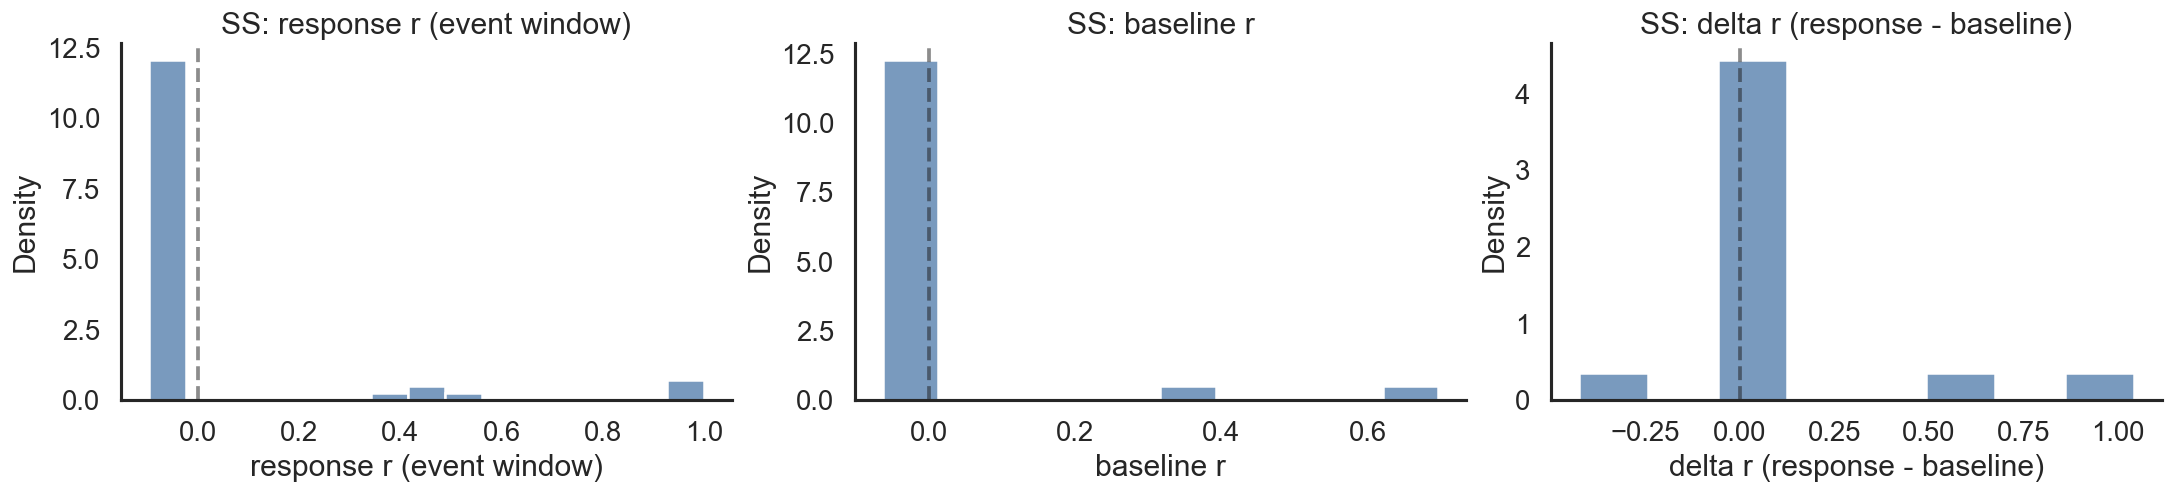

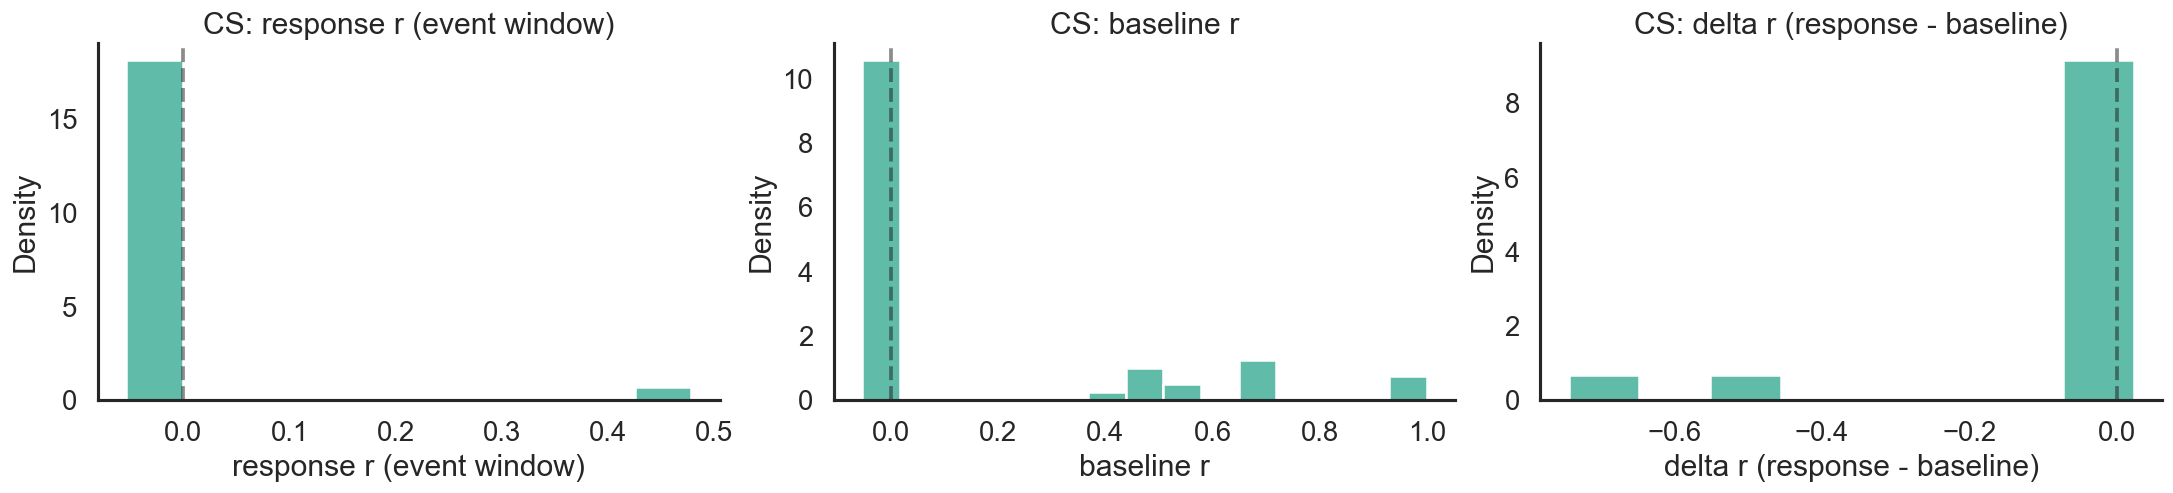

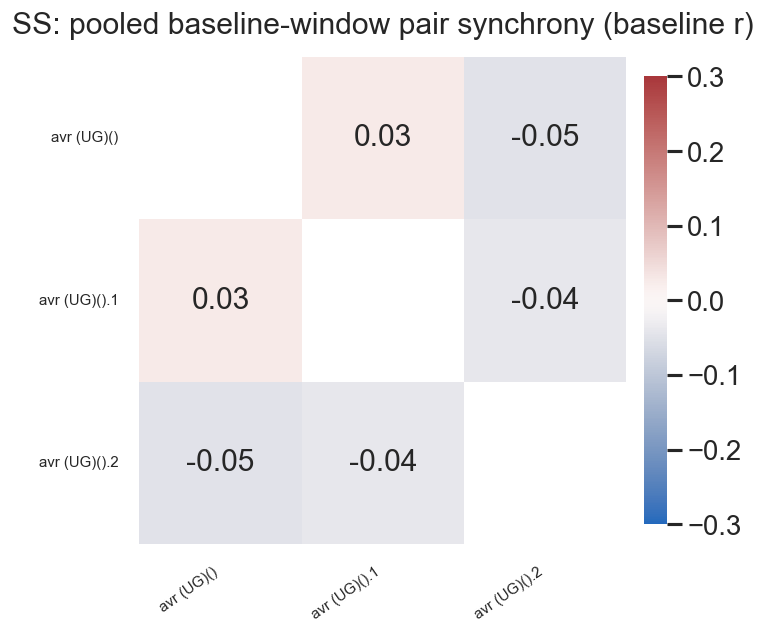

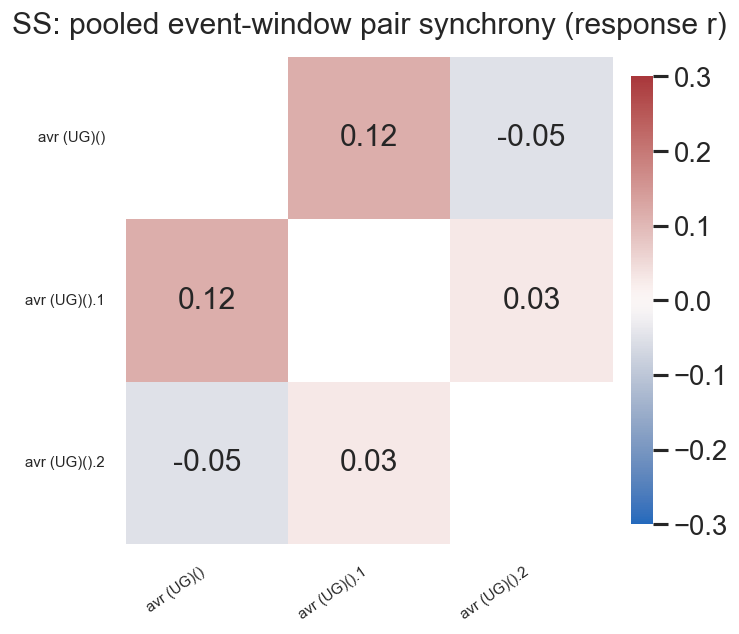

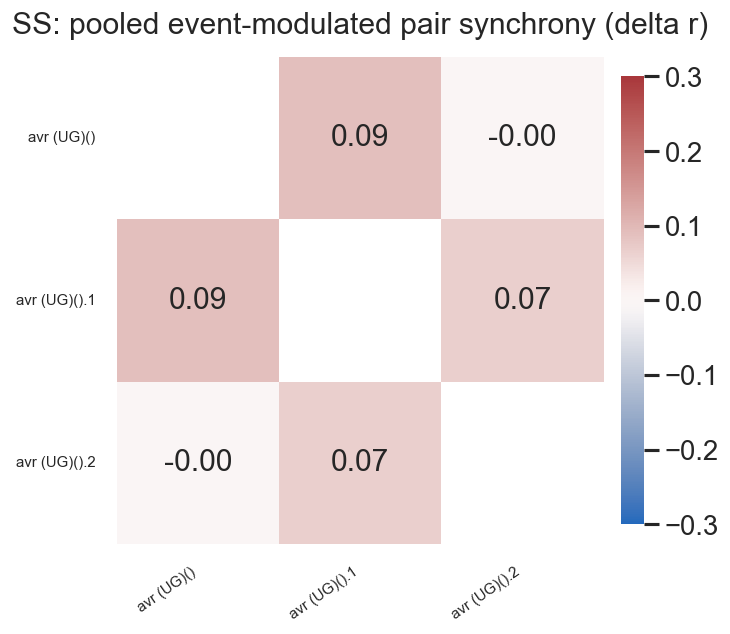

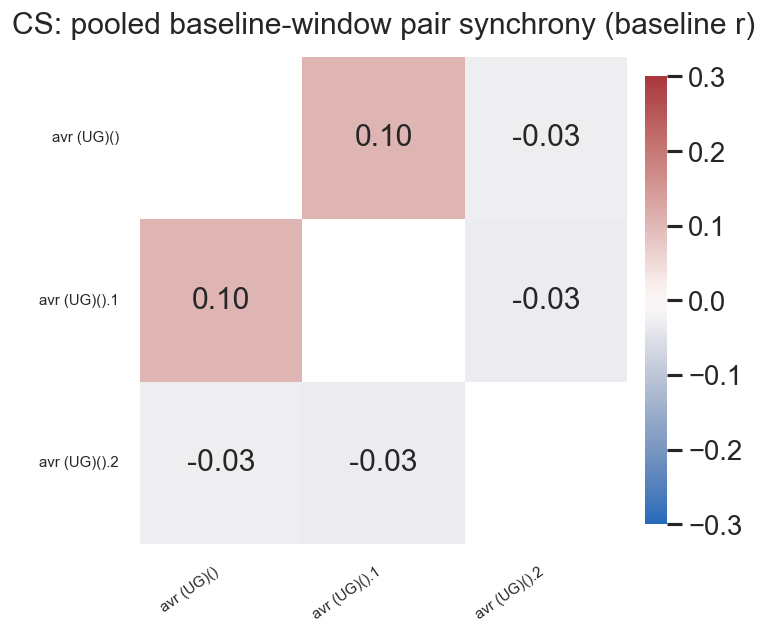

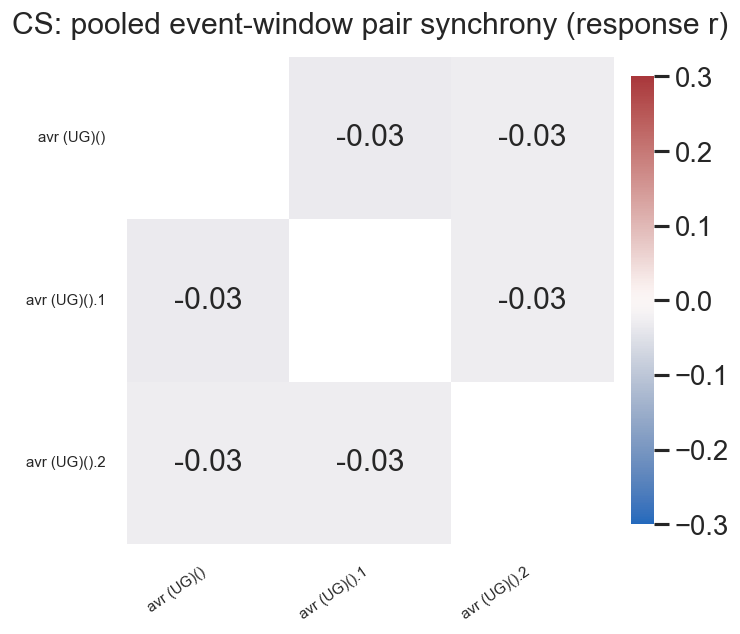

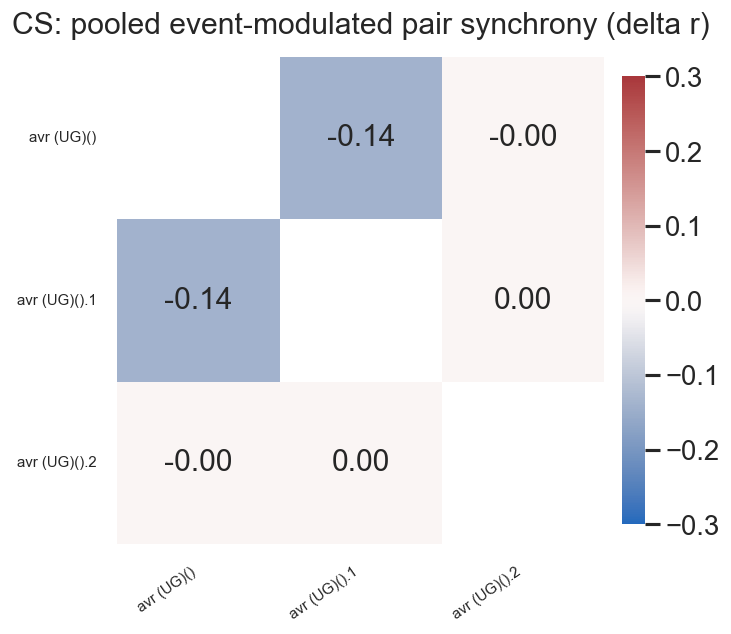

Max pooled consistency gap |delta_r_mean - (response_r_mean - baseline_r_mean)| = 2.776e-17


In [11]:
# Event-modulated paired synchrony: compare pairwise synchrony before vs after event

def windowed_pair_corr(times_a, times_b, event_time_ms, window_rel_ms, bin_ms):
    w0, w1 = window_rel_ms
    t0 = event_time_ms + float(w0)
    t1 = event_time_ms + float(w1)
    if t1 <= t0:
        return np.nan

    edges = np.arange(t0, t1 + bin_ms, bin_ms)
    if len(edges) < 3:
        return np.nan

    a_counts, _ = np.histogram(times_a, bins=edges)
    b_counts, _ = np.histogram(times_b, bins=edges)

    if np.std(a_counts) == 0 or np.std(b_counts) == 0:
        return np.nan

    return float(np.corrcoef(a_counts, b_counts)[0, 1])


def _plot_density_or_sticks(ax, vals, color, empty_msg):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        ax.text(0.5, 0.5, empty_msg, ha='center', va='center', transform=ax.transAxes)
        ax.axvline(0, color='k', ls='--', alpha=0.35)
        ax.set_xlim(-1, 1)
        return

    spread = float(np.ptp(vals))
    n_unique = int(np.unique(np.round(vals, 8)).size)

    # Degenerate/narrow distributions can fail in histogram bin edge estimation.
    if vals.size < 3 or n_unique < 3 or np.isclose(spread, 0.0):
        uniq, cnt = np.unique(np.round(vals, 6), return_counts=True)
        heights = cnt.astype(float) / float(np.max(cnt))
        ax.vlines(uniq, 0, heights, color=color, lw=4, alpha=0.9)
        ax.scatter(uniq, heights, color=color, s=26, zorder=3)
        ax.axvline(0, color='k', ls='--', alpha=0.5)
        if uniq.size == 1:
            span = max(1e-3, abs(float(uniq[0])) * 0.2 + 1e-3)
            ax.set_xlim(float(uniq[0]) - span, float(uniq[0]) + span)
        else:
            pad = max(1e-3, 0.15 * (float(np.max(uniq)) - float(np.min(uniq))))
            ax.set_xlim(float(np.min(uniq)) - pad, float(np.max(uniq)) + pad)
        return

    bins = int(np.clip(np.sqrt(vals.size) * 2.0, 5, 25))
    try:
        sns.histplot(vals, bins=bins, stat='density', color=color, ax=ax)
    except ValueError:
        # Final fallback for numeric edge cases.
        ax.vlines(vals, 0, 1, color=color, alpha=0.4)
    ax.axvline(0, color='k', ls='--', alpha=0.5)


def _draw_pair_heatmap(mat, cell_names, title, save_name):
    fig, ax = plt.subplots(figsize=(6.4, 5.8), constrained_layout=False)
    sns.heatmap(
        mat,
        cmap='vlag',
        center=0,
        square=True,
        xticklabels=cell_names,
        yticklabels=cell_names,
        annot=(len(cell_names) <= 10),
        fmt='.2f',
        cbar_kws={'shrink': 0.86, 'pad': 0.03},
        ax=ax,
    )
    ax.grid(False)
    ax.set_title(title, pad=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
    _save_fig_svg(fig, save_name)
    plt.show()


plt.close('all')

# Single-cell guard: no pairwise event-modulated synchrony can be computed.
if n_cells < 2:
    print('Single-cell dataset detected (n_cells=1). Skipping event-modulated paired synchrony analysis.')
    pair_event_sync_df = pd.DataFrame(columns=[
        'session', 'spike_type', 'i', 'j', 'cell_i', 'cell_j', 'r_baseline', 'r_response', 'delta_r'
    ])
    paired_sync_df = pair_event_sync_df.copy()
    pooled_pair_event = pd.DataFrame(columns=[
        'spike_type', 'cell_i', 'cell_j', 'n_sessions',
        'n_valid_baseline', 'n_valid_response', 'n_valid_delta', 'n_valid_paired',
        'baseline_r_mean', 'response_r_mean', 'delta_r_mean',
        'delta_from_means', 'delta_mean_gap'
    ])
    display(pair_event_sync_df.head())

else:
    rows = []
    event_cache = {}
    for s in sessions:
        event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache)
        for event_idx, event_time_ms in enumerate(event_times_ms):
            for spike_type in ['SS', 'CS']:
                spikes = s['spike_times_ss'] if spike_type == 'SS' else s['spike_times_cs']
                if spike_type == 'SS':
                    baseline_w = EVENT_CONFIG['ss_sync_baseline_ms']
                    response_w = EVENT_CONFIG['ss_sync_response_ms']
                    bin_ms = EVENT_CONFIG['ss_sync_bin_ms']
                else:
                    baseline_w = EVENT_CONFIG['cs_sync_baseline_ms']
                    response_w = EVENT_CONFIG['cs_sync_response_ms']
                    bin_ms = EVENT_CONFIG['cs_sync_bin_ms']

                for i, j in combinations(range(s['n_cells']), 2):
                    r_base = windowed_pair_corr(spikes[i], spikes[j], event_time_ms, baseline_w, bin_ms)
                    r_resp = windowed_pair_corr(spikes[i], spikes[j], event_time_ms, response_w, bin_ms)
                    rows.append({
                        'session': s['session_name'],
                        'event_idx': int(event_idx),
                        'event_time_ms': float(event_time_ms),
                        'event_source': s.get('event_source', 'manual'),
                        'spike_type': spike_type,
                        'i': i,
                        'j': j,
                        'cell_i': s['cell_names'][i],
                        'cell_j': s['cell_names'][j],
                        'r_baseline': r_base,
                        'r_response': r_resp,
                    })

    pair_event_sync_df = pd.DataFrame(rows)
    pair_event_sync_df['r_baseline'] = pd.to_numeric(pair_event_sync_df['r_baseline'], errors='coerce')
    pair_event_sync_df['r_response'] = pd.to_numeric(pair_event_sync_df['r_response'], errors='coerce')

    finite_pair = np.isfinite(pair_event_sync_df['r_baseline']) & np.isfinite(pair_event_sync_df['r_response'])
    pair_event_sync_df['delta_r'] = np.where(
        finite_pair,
        pair_event_sync_df['r_response'] - pair_event_sync_df['r_baseline'],
        np.nan,
    )

    print('Event-modulated paired synchrony table (first rows):')
    display(pair_event_sync_df.head())

    # Use complete paired observations so pooled baseline/response/delta are directly comparable.
    paired_sync_df = pair_event_sync_df.loc[finite_pair].copy()

    if paired_sync_df.empty:
        pooled_pair_event = pd.DataFrame(columns=[
            'spike_type', 'cell_i', 'cell_j', 'n_sessions',
            'baseline_r_mean', 'response_r_mean', 'delta_r_mean',
            'n_valid_baseline', 'n_valid_response', 'n_valid_delta', 'n_valid_paired',
            'delta_from_means', 'delta_mean_gap',
        ])
    else:
        pooled_pair_event = (
            paired_sync_df.groupby(['spike_type', 'cell_i', 'cell_j'], as_index=False)
            .agg(
                n_sessions=('session', 'nunique'),
                baseline_r_mean=('r_baseline', 'mean'),
                response_r_mean=('r_response', 'mean'),
                delta_r_mean=('delta_r', 'mean'),
                n_valid_paired=('delta_r', 'size'),
            )
        )

    support_counts = (
        pair_event_sync_df.assign(
            _valid_base=np.isfinite(pair_event_sync_df['r_baseline']),
            _valid_resp=np.isfinite(pair_event_sync_df['r_response']),
            _valid_delta=np.isfinite(pair_event_sync_df['delta_r']),
        )
        .groupby(['spike_type', 'cell_i', 'cell_j'], as_index=False)
        .agg(
            n_valid_baseline=('_valid_base', 'sum'),
            n_valid_response=('_valid_resp', 'sum'),
            n_valid_delta=('_valid_delta', 'sum'),
        )
    )

    if pooled_pair_event.empty:
        pooled_pair_event = support_counts.copy()
        pooled_pair_event['n_sessions'] = 0
        pooled_pair_event['baseline_r_mean'] = np.nan
        pooled_pair_event['response_r_mean'] = np.nan
        pooled_pair_event['delta_r_mean'] = np.nan
        pooled_pair_event['n_valid_paired'] = 0
    else:
        pooled_pair_event = pooled_pair_event.merge(
            support_counts,
            on=['spike_type', 'cell_i', 'cell_j'],
            how='left',
        )

    pooled_pair_event['delta_from_means'] = pooled_pair_event['response_r_mean'] - pooled_pair_event['baseline_r_mean']
    pooled_pair_event['delta_mean_gap'] = pooled_pair_event['delta_r_mean'] - pooled_pair_event['delta_from_means']

    print('Pooled event-modulated paired synchrony (across sessions):')
    display(pooled_pair_event)

    # Focus summary for Cell1-Cell2 and Cell1-Cell3
    if n_cells >= 3:
        focus = pair_event_sync_df[(pair_event_sync_df['spike_type'] == 'SS') &
                                   (((pair_event_sync_df['i'] == 0) & (pair_event_sync_df['j'] == 1)) |
                                    ((pair_event_sync_df['i'] == 0) & (pair_event_sync_df['j'] == 2)))].copy()
        if not focus.empty:
            focus_summary = (focus.groupby(['cell_i', 'cell_j'], as_index=False)
                             .agg(n_sessions=('session', 'nunique'),
                                  baseline_r_mean=('r_baseline', 'mean'),
                                  response_r_mean=('r_response', 'mean'),
                                  delta_r_mean=('delta_r', 'mean')))
            print('SS focus pairs (Cell1-Cell2 and Cell1-Cell3):')
            display(focus_summary)

    # Visualize distributions of response r, baseline r, and delta r
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
    for ax, value_col, label in zip(
        axes,
        ['r_response', 'r_baseline', 'delta_r'],
        ['response r (event window)', 'baseline r', 'delta r (response - baseline)']
    ):
        sub = pair_event_sync_df[pair_event_sync_df['spike_type'] == 'SS']
        vals = sub[value_col].dropna().to_numpy(dtype=float)
        _plot_density_or_sticks(ax, vals, '#4C78A8', f'No valid SS {value_col} values')
        ax.grid(False)
        ax.set_title(f'SS: {label}')
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
    _save_fig_svg(fig, 'event_sync_SS_distributions')
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
    for ax, value_col, label in zip(
        axes,
        ['r_response', 'r_baseline', 'delta_r'],
        ['response r (event window)', 'baseline r', 'delta r (response - baseline)']
    ):
        sub = pair_event_sync_df[pair_event_sync_df['spike_type'] == 'CS']
        vals = sub[value_col].dropna().to_numpy(dtype=float)
        _plot_density_or_sticks(ax, vals, '#2CA58D', f'No valid CS {value_col} values')
        ax.grid(False)
        ax.set_title(f'CS: {label}')
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
    _save_fig_svg(fig, 'event_sync_CS_distributions')
    plt.show()

    # Heatmaps of pooled baseline_r, response_r, and delta_r by pair using paired-valid rows.
    for stype in ['SS', 'CS']:
        sub = paired_sync_df[paired_sync_df['spike_type'] == stype]

        if sub.empty:
            fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
            ax.grid(False)
            ax.axis('off')
            ax.text(0.5, 0.5, f'{stype}: no valid paired baseline/response values',
                    ha='center', va='center', fontsize=12)
            plt.show()
            continue

        pair_means = (
            sub.groupby(['i', 'j'], as_index=False)
            .agg(
                r_baseline_mean=('r_baseline', 'mean'),
                r_response_mean=('r_response', 'mean'),
            )
        )
        pair_means['delta_r_mean'] = pair_means['r_response_mean'] - pair_means['r_baseline_mean']

        base_mat = np.full((n_cells, n_cells), np.nan, dtype=float)
        resp_mat = np.full((n_cells, n_cells), np.nan, dtype=float)
        delta_mat = np.full((n_cells, n_cells), np.nan, dtype=float)

        for row in pair_means.itertuples(index=False):
            i, j = int(row.i), int(row.j)
            base_mat[i, j] = base_mat[j, i] = float(row.r_baseline_mean)
            resp_mat[i, j] = resp_mat[j, i] = float(row.r_response_mean)
            delta_mat[i, j] = delta_mat[j, i] = float(row.delta_r_mean)

        np.fill_diagonal(base_mat, np.nan)
        np.fill_diagonal(resp_mat, np.nan)
        np.fill_diagonal(delta_mat, np.nan)

        _draw_pair_heatmap(
            base_mat,
            cell_names,
            f'{stype}: pooled baseline-window pair synchrony (baseline r)',
            f'event_sync_{stype}_baseline_heatmap',
        )
        _draw_pair_heatmap(
            resp_mat,
            cell_names,
            f'{stype}: pooled event-window pair synchrony (response r)',
            f'event_sync_{stype}_response_heatmap',
        )
        _draw_pair_heatmap(
            delta_mat,
            cell_names,
            f'{stype}: pooled event-modulated pair synchrony (delta r)',
            f'event_sync_{stype}_delta_r_heatmap',
        )

    if not pooled_pair_event.empty:
        max_gap = float(np.nanmax(np.abs(pooled_pair_event['delta_mean_gap'].to_numpy(dtype=float))))
        print(f'Max pooled consistency gap |delta_r_mean - (response_r_mean - baseline_r_mean)| = {max_gap:.3e}')

[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_Stat

,session,spike_type,mod_index_mean,mod_index_sem,pct_change_mean
0,puff_1,CS,-0.233333,0.180973,-42.424242
1,puff_1,SS,0.248254,0.138441,54.220779
2,puff_10,CS,-0.377778,0.207955,-90.000000
3,puff_10,SS,0.338413,0.143581,75.757576
4,puff_2,CS,-0.408889,0.135673,-45.833333
5,puff_2,SS,0.424444,0.115675,109.090909
6,puff_3,CS,-0.066667,0.211320,-40.000000
7,puff_3,SS,0.193651,0.096364,90.000000
8,puff_5,CS,-0.391111,0.116903,-46.153846
9,puff_5,SS,0.335527,0.113675,93.939394


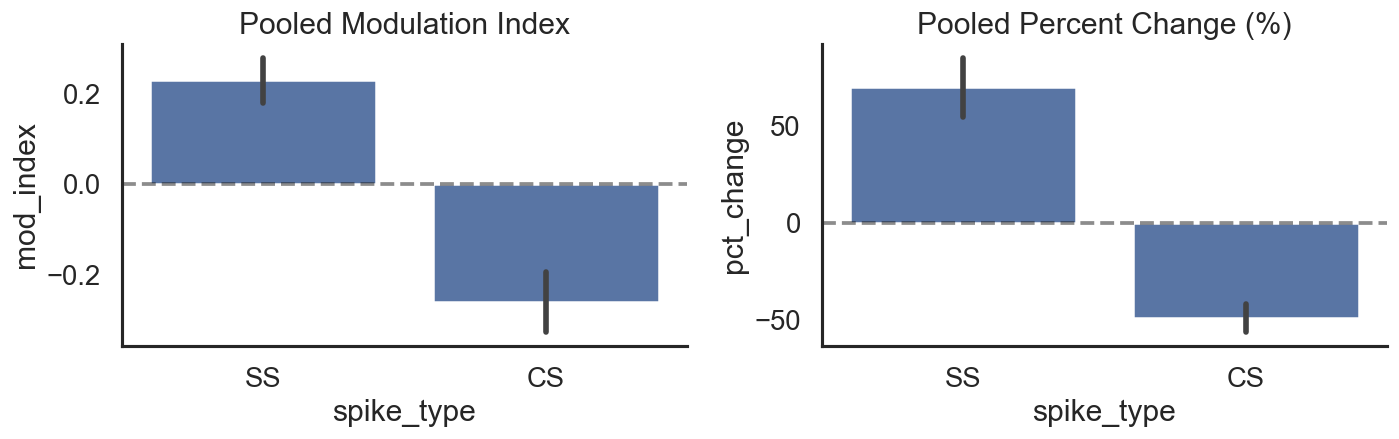

Pooled event-modulated spike likelihood (binary occurrence):


,spike_type,baseline_likelihood,response_likelihood,delta_likelihood
0,CS,0.752381,0.533333,-0.219048
1,SS,0.771429,0.895238,0.123810


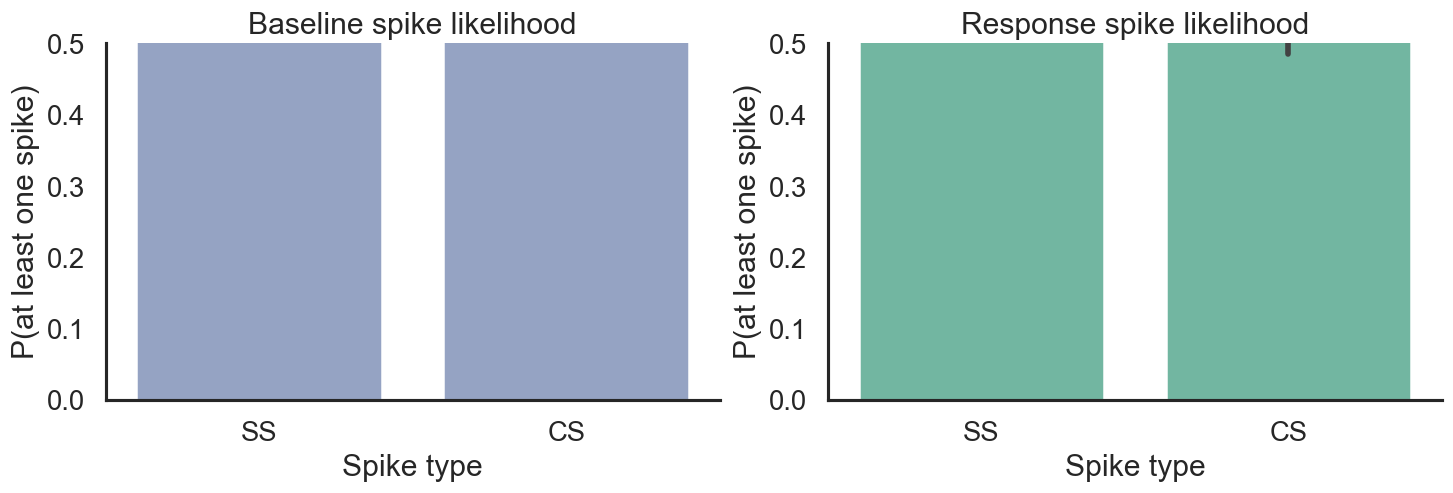

[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)


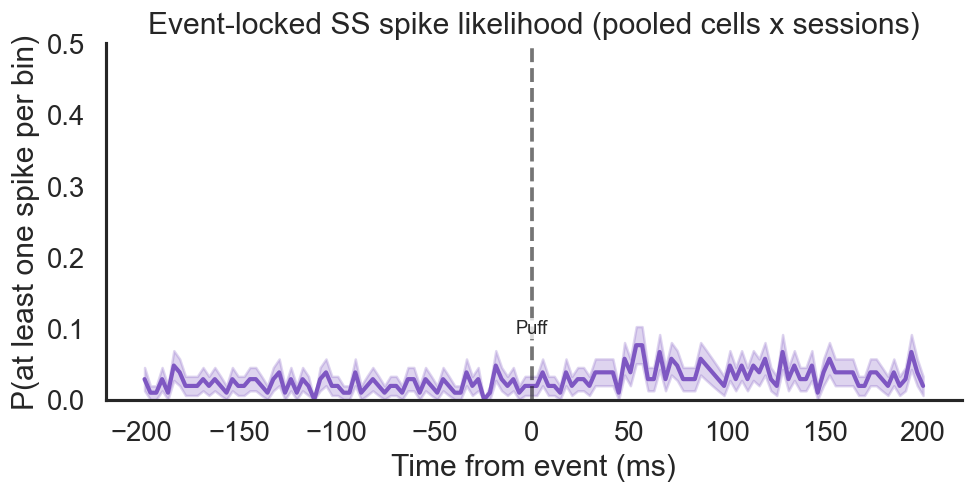

[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)


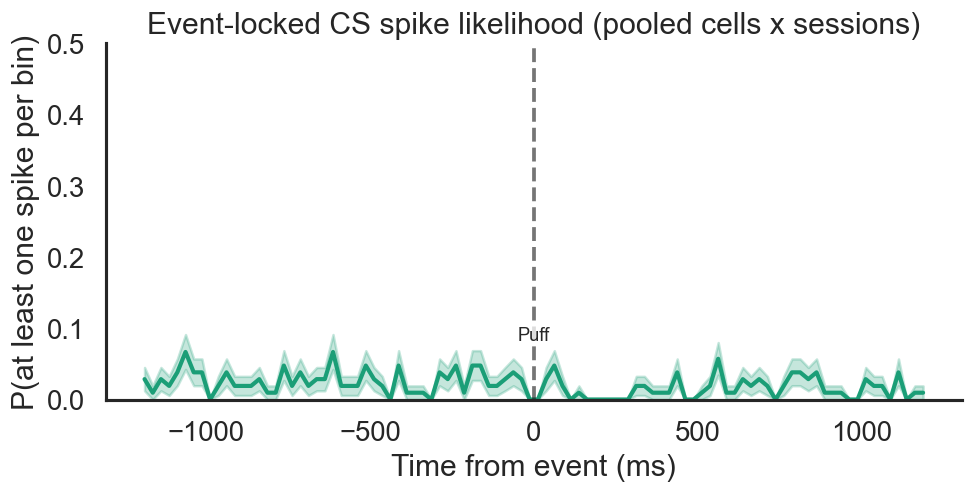

[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)


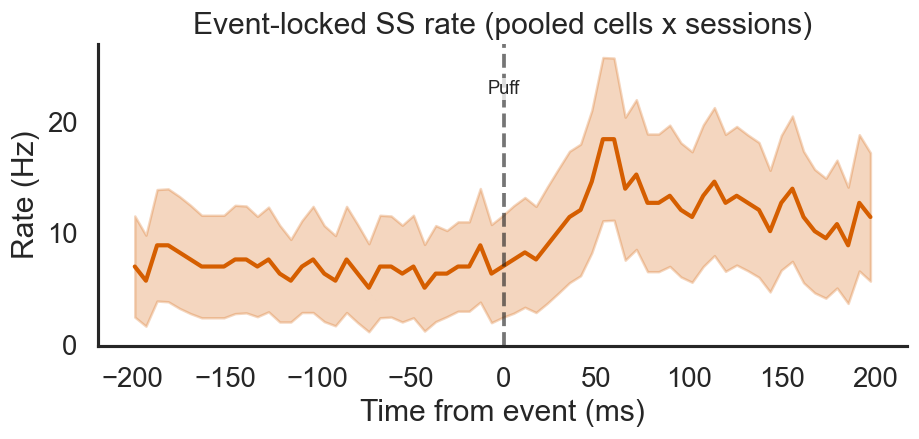

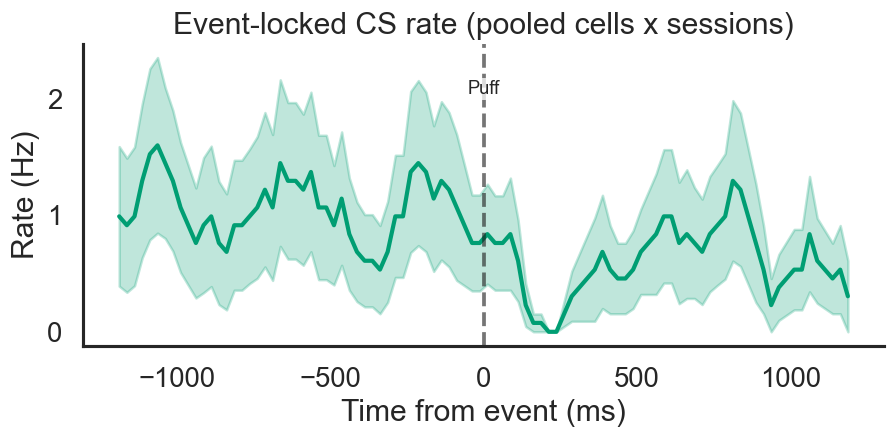


Per-cell pooled modulation summary:


,cell,spike_type,n_sessions,baseline_hz_mean,response_hz_mean,mod_index_mean,pct_change_mean
0,avr (UG)(),CS,7,0.880952,0.785714,-0.033333,-36.666667
1,avr (UG)(),SS,7,8.142857,14.142857,0.298015,97.592593
2,avr (UG)().1,CS,7,1.619048,0.785714,-0.374286,-40.656566
3,avr (UG)().1,SS,7,7.142857,14.857143,0.382041,99.190476
4,avr (UG)().2,CS,7,0.642857,0.238095,-0.371429,-76.190476
5,avr (UG)().2,SS,7,5.714286,7.000000,0.006667,18.390805



Per-cell SS event-locked rate curves:
[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)


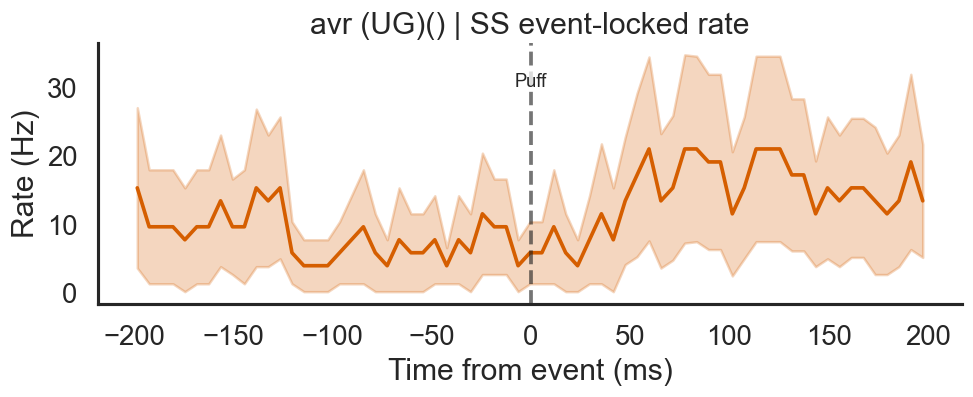

[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)


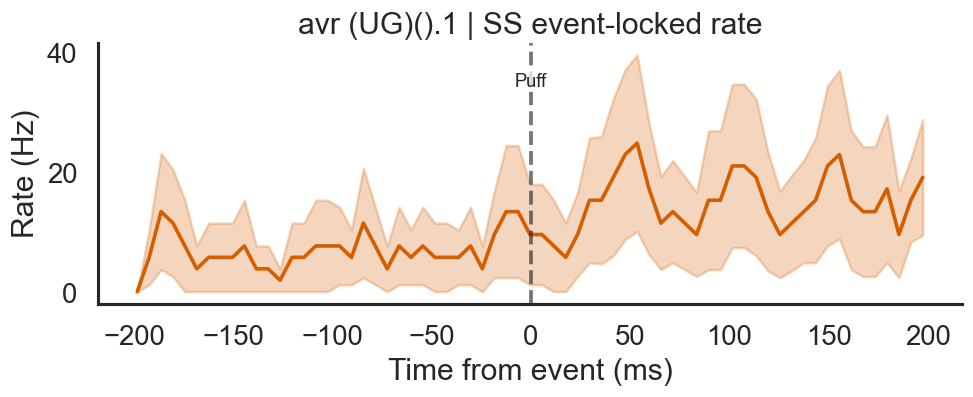

[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)


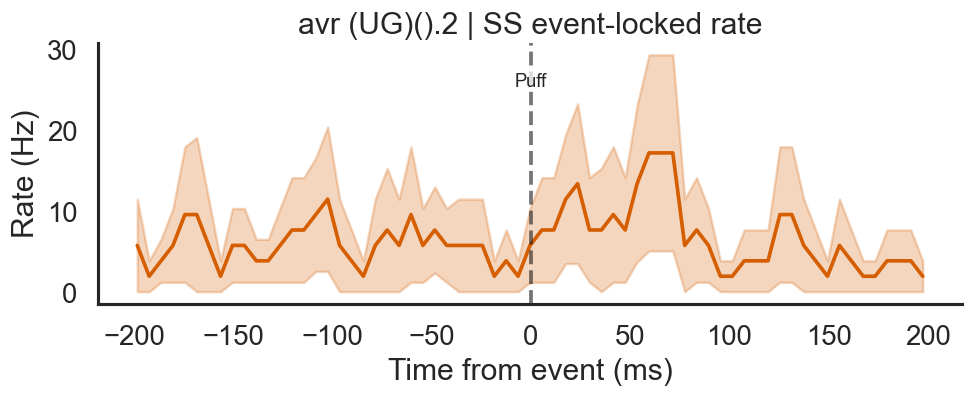

In [12]:
# Refresh pooled event modulation each run to avoid stale pooled curves after config/data changes.
event_df, pooled_event = run_event_modulation(sessions, EVENT_CONFIG)
if EVENT_LIKELIHOOD_CONFIG.get('enabled', True):
    event_likelihood_df = run_event_spike_likelihood(sessions, EVENT_CONFIG)
else:
    event_likelihood_df = pd.DataFrame()
plt.close('all')

def _smooth_curve(y, window=5):
    y = np.asarray(y, dtype=float)
    window = int(max(1, window))
    if window <= 1 or y.size < window:
        return y
    if window % 2 == 0:
        window += 1
    pad = window // 2
    kernel = np.ones(window, dtype=float) / float(window)
    ypad = np.pad(y, (pad, pad), mode='edge')
    return np.convolve(ypad, kernel, mode='valid')

# Per-session modulation summary
if not event_df.empty:
    session_mod = (event_df.groupby(['session', 'spike_type'], as_index=False)
                       .agg(mod_index_mean=('mod_index', 'mean'),
                            mod_index_sem=('mod_index', lambda x: np.std(x, ddof=1) / np.sqrt(max(len(x), 1))),
                            pct_change_mean=('pct_change', 'mean')))
    display(session_mod)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Modulation index bar plot
    mod_df = event_df.dropna(subset=['mod_index']).copy()
    if not mod_df.empty:
        sns.barplot(data=mod_df, x='spike_type', y='mod_index', order=['SS', 'CS'], errorbar='se', ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, 'No valid modulation index values', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].grid(False)
    axes[0].axhline(0, color='k', ls='--', alpha=0.5)
    axes[0].set_title('Pooled Modulation Index')

    # Percent-change bar plot
    pct_df = event_df.dropna(subset=['pct_change']).copy()
    if not pct_df.empty:
        sns.barplot(data=pct_df, x='spike_type', y='pct_change', order=['SS', 'CS'], errorbar='se', ax=axes[1])
    else:
        axes[1].text(0.5, 0.5, 'No valid percent-change values', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].grid(False)
    axes[1].axhline(0, color='k', ls='--', alpha=0.5)
    axes[1].set_title('Pooled Percent Change (%)')

    # Make missing categories explicit (e.g., CS can be all-NaN for pct_change).
    for ax, metric, title_name in [
        (axes[0], 'mod_index', 'Modulation index'),
        (axes[1], 'pct_change', 'Percent change')
    ]:
        valid_types = set(event_df.loc[event_df[metric].notna(), 'spike_type'].unique().tolist())
        missing_types = [t for t in ['SS', 'CS'] if t not in valid_types]
        if missing_types:
            ax.text(0.98, 0.98,
                    f"{title_name} unavailable for: {', '.join(missing_types)}",
                    ha='right', va='top', fontsize=10, transform=ax.transAxes)

    plt.tight_layout()
    _save_fig_svg(fig, 'pooled_modulation_index_pct_change')
    plt.show()

# Event-modulated spike likelihood summary/plot (binary occurrence in configured windows).
if not event_likelihood_df.empty:
    like_summary = (event_likelihood_df.groupby('spike_type', as_index=False)
                    .agg(baseline_likelihood=('baseline_likelihood', 'mean'),
                         response_likelihood=('response_likelihood', 'mean'),
                         delta_likelihood=('delta_likelihood', 'mean')))
    print('Pooled event-modulated spike likelihood (binary occurrence):')
    display(like_summary)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    sns.barplot(data=event_likelihood_df, x='spike_type', y='baseline_likelihood', order=['SS', 'CS'], errorbar='se', ax=axes[0], color='#8DA0CB')
    sns.barplot(data=event_likelihood_df, x='spike_type', y='response_likelihood', order=['SS', 'CS'], errorbar='se', ax=axes[1], color='#66C2A5')
    for ax, ttl in zip(axes, ['Baseline spike likelihood', 'Response spike likelihood']):
        ax.grid(False)
        ax.set_ylim(0, 0.5)
        ax.set_xlabel('Spike type')
        ax.set_ylabel('P(at least one spike)')
        ax.set_title(ttl)
    _save_fig_svg(fig, 'spike_likelihood_baseline_response')
    plt.show()

# Continuous event-locked spike likelihood curves (analogous to event-locked rate curves).
for stype in ['SS', 'CS']:
    if stype == 'SS':
        bin_ms = EVENT_CONFIG['ss_bin_ms']
        w = EVENT_CONFIG['ss_window_ms']
        c = '#7E57C2'
        spikes_accessor = 'spike_times_ss'
    else:
        bin_ms = EVENT_CONFIG['cs_bin_ms']
        w = EVENT_CONFIG['cs_window_ms']
        c = '#1B9E77'
        spikes_accessor = 'spike_times_cs'

    likelihood_rows = []
    event_cache = {}
    for i in range(len(cell_names)):
        for s in sessions:
            event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache)
            for event_time_ms in event_times_ms:
                _, lk = event_locked_bin_likelihood(
                    s[spikes_accessor][i],
                    event_time_ms,
                    w,
                    bin_ms,
                )
                likelihood_rows.append(lk)

    if len(likelihood_rows) == 0:
        continue
    lk_arr = np.asarray(likelihood_rows, dtype=float)
    lk_mean = np.nanmean(lk_arr, axis=0)
    lk_sem = np.nanstd(lk_arr, axis=0, ddof=1) / np.sqrt(lk_arr.shape[0]) if lk_arr.shape[0] > 1 else np.zeros_like(lk_mean)
    x = np.arange(w[0], w[1], bin_ms) + bin_ms / 2

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.grid(False)
    ax.plot(x, lk_mean, color=c, lw=2.5)
    ax.fill_between(x, np.clip(lk_mean - lk_sem, 0, 1), np.clip(lk_mean + lk_sem, 0, 1), color=c, alpha=0.25)
    ax.axvline(0, color='k', ls='--', alpha=0.6)
    ymin, ymax = ax.get_ylim()
    y_txt = ymin + 0.82 * (ymax - ymin)
    ax.text(0.0, y_txt, 'Puff', ha='center', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.0))
    if np.allclose(lk_mean, 0.0):
        ax.text(0.98, 0.96, f'No {stype} spikes in configured event window',
                ha='right', va='top', fontsize=10, transform=ax.transAxes)
    ax.set_ylim(0, 0.5)
    ax.set_title(f'Event-locked {stype} spike likelihood (pooled cells x sessions)')
    ax.set_xlabel('Time from event (ms)')
    ax.set_ylabel('P(at least one spike per bin)')
    _save_fig_svg(fig, f'event_locked_{stype}_likelihood')
    plt.show()

# PETH pooled curves
# Use configured SS window directly (no extra zoom expansion).
ss_display_window = EVENT_CONFIG['ss_window_ms']
ss_point_stride = 2

cs_nonzero = False
for stype in ['SS', 'CS']:
    if stype == 'SS':
        bin_ms = EVENT_CONFIG['ss_bin_ms']
        w = ss_display_window
        c = '#D55E00'

        # Recompute pooled SS rates using the configured display window.
        ss_rates = []
        event_cache = {}
        for i in range(len(cell_names)):
            for s in sessions:
                event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache)
                for event_time_ms in event_times_ms:
                    _, rate, _ = event_locked_hist(
                        s['spike_times_ss'][i],
                        event_time_ms,
                        w,
                        bin_ms,
                    )
                    ss_rates.append(rate)
        if len(ss_rates) == 0:
            continue
        arr = np.asarray(ss_rates, dtype=float)
    else:
        if len(pooled_event[stype]) == 0:
            continue
        arr = np.asarray(pooled_event[stype], dtype=float)
        bin_ms = EVENT_CONFIG['cs_bin_ms']
        w = EVENT_CONFIG['cs_window_ms']
        c = '#009E73'

    mean_curve = np.nanmean(arr, axis=0)
    sem_curve = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(mean_curve)

    if stype == 'CS':
        cs_nonzero = bool(np.any(mean_curve > 0))

    x = np.arange(w[0], w[1], bin_ms) + bin_ms / 2

    # Smooth curves; for SS also downsample plotted points to 2x sparser.
    mean_plot = _smooth_curve(mean_curve, window=5)
    sem_plot = _smooth_curve(sem_curve, window=5)
    x_plot = x
    if stype == 'SS':
        x_plot = x_plot[::ss_point_stride]
        mean_plot = mean_plot[::ss_point_stride]
        sem_plot = sem_plot[::ss_point_stride]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.grid(False)
    ax.plot(x_plot, mean_plot, color=c, lw=2.5)
    ax.fill_between(x_plot, mean_plot - sem_plot, mean_plot + sem_plot, color=c, alpha=0.25)
    ax.axvline(0, color='k', ls='--', alpha=0.6)
    ymin, ymax = ax.get_ylim()
    y_txt = ymin + 0.82 * (ymax - ymin)
    ax.text(0.0, y_txt, 'Puff', ha='center', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.0))
    if np.allclose(mean_curve, 0.0):
        ax.text(0.98, 0.96, f'No {stype} spikes in configured event window',
                ha='right', va='top', fontsize=10, transform=ax.transAxes)
    ax.set_title(f'Event-locked {stype} rate (pooled cells x sessions)')
    ax.set_xlabel('Time from event (ms)')
    ax.set_ylabel('Rate (Hz)')
    plt.tight_layout()
    _save_fig_svg(fig, f'event_locked_{stype}_rate')
    plt.show()

if not cs_nonzero:
    print('CS is absent or near-absent in the current event windows; showing detailed SS modulation per cell below.')

# Per-cell modulation summary table (across sessions) — bar plots removed per request
cell_mod = (event_df.groupby(['cell', 'spike_type'], as_index=False)
            .agg(n_sessions=('session', 'nunique'),
                 baseline_hz_mean=('baseline_hz', 'mean'),
                 response_hz_mean=('response_hz', 'mean'),
                 mod_index_mean=('mod_index', 'mean'),
                 pct_change_mean=('pct_change', 'mean')))
print('\nPer-cell pooled modulation summary:')
display(cell_mod)

# Per-cell SS event-locked rate curves
print('\nPer-cell SS event-locked rate curves:')
for i, cname in enumerate(cell_names):
    ss_rates = []
    event_cache = {}
    for s in sessions:
        event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache)
        for event_time_ms in event_times_ms:
            _, rate, _ = event_locked_hist(
                s['spike_times_ss'][i],
                event_time_ms,
                ss_display_window,
                EVENT_CONFIG['ss_bin_ms']
            )
            ss_rates.append(rate)

    arr = np.asarray(ss_rates, dtype=float)
    mean_curve = np.nanmean(arr, axis=0)
    sem_curve = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(mean_curve)
    w = ss_display_window
    bin_ms = EVENT_CONFIG['ss_bin_ms']
    x = np.arange(w[0], w[1], bin_ms) + bin_ms / 2

    mean_plot = _smooth_curve(mean_curve, window=5)[::ss_point_stride]
    sem_plot = _smooth_curve(sem_curve, window=5)[::ss_point_stride]
    x_plot = x[::ss_point_stride]

    fig, ax = plt.subplots(figsize=(8, 3.2), constrained_layout=True)
    ax.grid(False)
    ax.plot(x_plot, mean_plot, color='#D55E00', lw=2.2)
    ax.fill_between(x_plot, mean_plot - sem_plot, mean_plot + sem_plot, color='#D55E00', alpha=0.25)
    ax.axvline(0, color='k', ls='--', alpha=0.6)
    ymin, ymax = ax.get_ylim()
    y_txt = ymin + 0.82 * (ymax - ymin)
    ax.text(0.0, y_txt, 'Puff', ha='center', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.0))
    ax.set_title(f'{cname} | SS event-locked rate')
    ax.set_xlabel('Time from event (ms)')
    ax.set_ylabel('Rate (Hz)')
    _save_fig_svg(fig, f'per_cell_SS_rate_{cname}')
    plt.show()


Per-pair event-locked synchrony curves:
[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20

/var/folders/cp/q8802h992_371mtbyj83fz1h0000gn/T/ipykernel_68466/249298860.py:85: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(arr, axis=0)


[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State,

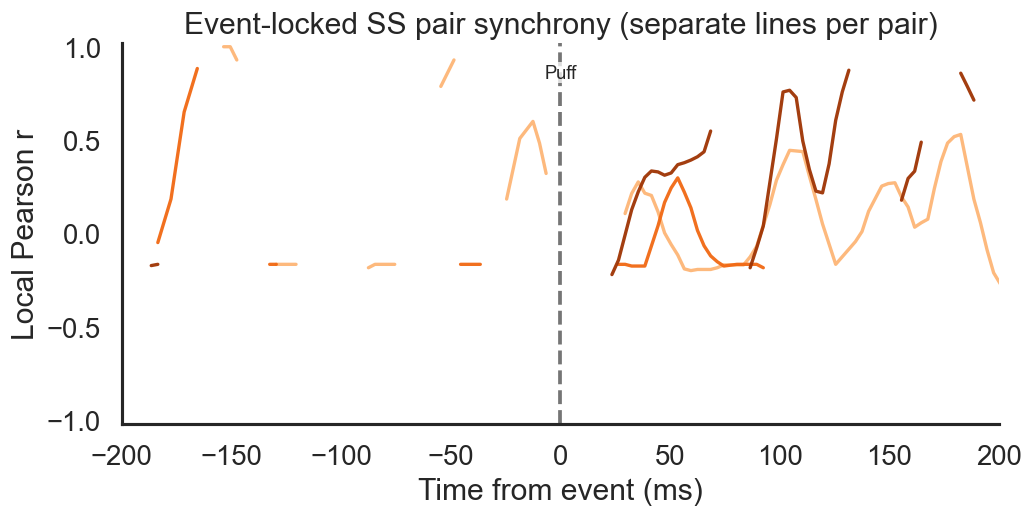

[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_puff_7_20260408_172401.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_8: detected 5 event(s) from A49_3PCs_puff_8_20260408_172542.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_Stat

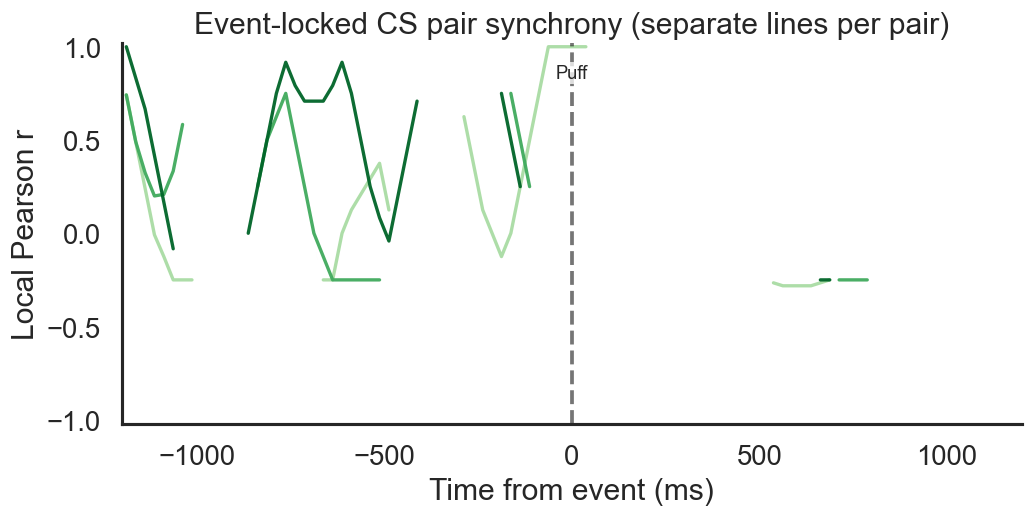

In [25]:
# Event-locked pair synchrony timecourses (separate line per pair), using consistent event windows.

def event_locked_pair_sync_curve(times_a, times_b, event_time_ms, window_ms, bin_ms, sync_window_ms):
    w0, w1 = float(window_ms[0]), float(window_ms[1])
    t0 = event_time_ms + w0
    t1 = event_time_ms + w1
    if t1 <= t0:
        return np.array([], dtype=float), np.array([], dtype=float)

    edges = np.arange(t0, t1 + bin_ms, bin_ms)
    if len(edges) < 4:
        return np.array([], dtype=float), np.array([], dtype=float)

    a_counts, _ = np.histogram(times_a, bins=edges)
    b_counts, _ = np.histogram(times_b, bins=edges)
    centers = edges[:-1] + (bin_ms / 2.0) - event_time_ms

    half_bins = max(1, int(round((sync_window_ms / max(bin_ms, 1e-9)) / 2.0)))
    curve = np.full(centers.shape, np.nan, dtype=float)

    for k in range(len(centers)):
        i0 = max(0, k - half_bins)
        i1 = min(len(centers), k + half_bins + 1)
        if (i1 - i0) < 3:
            continue

        a_seg = a_counts[i0:i1].astype(float)
        b_seg = b_counts[i0:i1].astype(float)
        if np.std(a_seg) == 0 or np.std(b_seg) == 0:
            continue

        curve[k] = float(np.corrcoef(a_seg, b_seg)[0, 1])

    return centers, curve

print('\nPer-pair event-locked synchrony curves:')

if n_cells < 2:
    print('Single-cell dataset detected (n_cells=1). Skipping per-pair event-locked synchrony curves.')
else:
    for stype in ['SS', 'CS']:
        if stype == 'SS':
            spikes_key = 'spike_times_ss'
            bin_ms = float(EVENT_CONFIG['ss_sync_bin_ms'])
            w = EVENT_CONFIG['ss_window_ms']
            color_map = plt.cm.Oranges
        else:
            spikes_key = 'spike_times_cs'
            bin_ms = float(EVENT_CONFIG['cs_sync_bin_ms'])
            w = EVENT_CONFIG['cs_window_ms']
            color_map = plt.cm.Greens

        # Use dedicated sync curve window from config (NOT the response window).
        sync_window_ms = float(EVENT_CONFIG.get(
            f'{stype.lower()}_sync_curve_window_ms',
            20.0 if stype == 'SS' else 100.0
        ))

        pair_curves = {}
        x_ref = None
        for i, j in combinations(range(n_cells), 2):
            curves = []
            _event_cache_sync_curve = {}
            for s in sessions:
                event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=_event_cache_sync_curve)
                for event_time_ms in event_times_ms:
                    x, y = event_locked_pair_sync_curve(
                        s[spikes_key][i],
                        s[spikes_key][j],
                        event_time_ms,
                        w,
                        bin_ms,
                        sync_window_ms,
                    )
                    if y.size == 0 or np.all(np.isnan(y)):
                        continue
                    curves.append(y)
                    if x_ref is None:
                        x_ref = x

            if len(curves) == 0:
                continue

            arr = np.asarray(curves, dtype=float)
            mean_curve = np.nanmean(arr, axis=0)
            if np.all(np.isnan(mean_curve)):
                continue
            pair_curves[(i, j)] = _smooth_curve(mean_curve, window=5)

        fig, ax = plt.subplots(figsize=(8.5, 4.2), constrained_layout=True)
        ax.grid(False)

        if not pair_curves or x_ref is None:
            ax.text(0.5, 0.5, f'No valid {stype} pair synchrony curves', ha='center', va='center', transform=ax.transAxes)
            ax.axvline(0, color='k', ls='--', alpha=0.6)
            ax.set_xlim(float(w[0]), float(w[1]))
            ax.set_ylim(-1.02, 1.02)
            ax.set_title(f'Event-locked {stype} pair synchrony')
            ax.set_xlabel('Time from event (ms)')
            ax.set_ylabel('Local Pearson r')
            _save_fig_svg(fig, f'event_locked_{stype}_pair_sync_empty')
            plt.show()
            continue

        pair_keys = sorted(pair_curves.keys())
        colors = color_map(np.linspace(0.35, 0.9, len(pair_keys)))
        for c_idx, (i, j) in enumerate(pair_keys):
            label = f'{cell_names[i]} vs {cell_names[j]}'
            ax.plot(x_ref, pair_curves[(i, j)], lw=2.0, color=colors[c_idx], alpha=0.95, label=label)

        ax.axvline(0, color='k', ls='--', alpha=0.6)
        ymin, ymax = ax.get_ylim()
        y_txt = ymin + 0.82 * (ymax - ymin)
        ax.text(0.0, y_txt, 'Puff', ha='center', va='bottom', fontsize=11,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.0))
        ax.set_xlim(float(w[0]), float(w[1]))
        ax.set_ylim(-1.02, 1.02)
        ax.set_title(f'Event-locked {stype} pair synchrony (separate lines per pair)')
        ax.set_xlabel('Time from event (ms)')
        ax.set_ylabel('Local Pearson r')

        _save_fig_svg(fig, f'event_locked_{stype}_pair_sync')
        plt.show()


In [27]:
# Pair-level jitter-null with BH-FDR (primary metric = direct windowed correlation)
# Configurable significance tail mode:
#   right (default), left, or two-sided.


def _resolve_tail_mode():
    cfg = globals().get('SIGNIFICANCE_TEST_CONFIG', {})
    raw = str(cfg.get('tail', 'right')).strip().lower()
    if raw in {'right', 'right-sided', 'right_sided'}:
        return 'right'
    if raw in {'left', 'left-sided', 'left_sided'}:
        return 'left'
    if raw in {'two-sided', 'two_sided', 'two sided', 'two', 'both'}:
        return 'two-sided'
    return 'right'


def _active_p_info(tail_mode):
    if tail_mode == 'left':
        return 'p_left', 'P(null <= observed)'
    if tail_mode == 'two-sided':
        return 'p_two_sided', 'min(1, 2 * min(p_left, p_right))'
    return 'p_right', 'P(null >= observed)'


def _bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    if n == 0:
        return np.array([], dtype=float)
    order = np.argsort(p)
    ranks = np.empty(n, dtype=float)
    ranks[order] = np.arange(1, n + 1, dtype=float)
    q = p * n / ranks
    q_sorted = q[order].copy()
    for k in range(n - 2, -1, -1):
        if q_sorted[k] > q_sorted[k + 1]:
            q_sorted[k] = q_sorted[k + 1]
    q[order] = q_sorted
    return np.clip(q, 0.0, 1.0)


def _window_union(*windows):
    return (min(float(w[0]) for w in windows), max(float(w[1]) for w in windows))


def _jitter_within_window(times, event_time_ms, window_ms, jitter_ms, rng_obj):
    t = np.asarray(times, dtype=float)
    if t.size == 0:
        return t
    lo = float(event_time_ms) + float(window_ms[0])
    hi = float(event_time_ms) + float(window_ms[1])
    in_win = (t >= lo) & (t <= hi)
    if not np.any(in_win):
        return np.sort(t.copy())
    out = t.copy()
    out[in_win] = out[in_win] + rng_obj.uniform(-jitter_ms, jitter_ms, size=int(in_win.sum()))
    out[in_win] = np.clip(out[in_win], lo, hi)
    return np.sort(out)


def _delta_r_direct(times_a, times_b, event_time_ms, baseline_w, response_w, bin_ms):
    r_base = windowed_pair_corr(times_a, times_b, event_time_ms, baseline_w, bin_ms)
    r_resp = windowed_pair_corr(times_a, times_b, event_time_ms, response_w, bin_ms)
    if np.isfinite(r_base) and np.isfinite(r_resp):
        return float(r_resp - r_base)
    return np.nan


tail_mode = _resolve_tail_mode()
active_p_col, active_p_desc = _active_p_info(tail_mode)

print('── Pair-level jitter-null with BH-FDR (direct windowed correlation) ──\n')
print(
    f"Tail mode: {tail_mode} | active p column: {active_p_col} ({active_p_desc})\n"
    f"q_bh_fdr is BH-corrected from {active_p_col} within each spike type."
)

if n_cells < 2:
    print('Single-cell dataset. Skipping pair-level jitter-null.')
    pair_fdr_df = pd.DataFrame()
else:
    pair_rows = []

    for stype in ['SS', 'CS']:
        if stype == 'SS':
            spikes_key = 'spike_times_ss'
            inspect_w = EVENT_CONFIG['ss_window_ms']
            baseline_w = EVENT_CONFIG['ss_sync_baseline_ms']
            response_w = EVENT_CONFIG['ss_sync_response_ms']
            bin_ms = float(EVENT_CONFIG['ss_sync_bin_ms'])
            jitter_ms = float(JITTER_TEST_CONFIG['ss_jitter_ms'])
        else:
            spikes_key = 'spike_times_cs'
            inspect_w = EVENT_CONFIG['cs_window_ms']
            baseline_w = EVENT_CONFIG['cs_sync_baseline_ms']
            response_w = EVENT_CONFIG['cs_sync_response_ms']
            bin_ms = float(EVENT_CONFIG['cs_sync_bin_ms'])
            jitter_ms = float(JITTER_TEST_CONFIG['cs_jitter_ms'])

        analysis_w = _window_union(inspect_w, baseline_w, response_w)
        n_null = int(JITTER_TEST_CONFIG['n_null_shuffles'])
        rng_pair = np.random.default_rng(int(JITTER_TEST_CONFIG['pair_fdr_seed']))

        print(f"{stype}: inspect={inspect_w}, baseline={baseline_w}, response={response_w}, jitter_window={analysis_w}")

        for i, j in combinations(range(n_cells), 2):
            observed_vals = []
            _event_cache_obs = {}
            for s in sessions:
                event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=_event_cache_obs)
                for event_time_ms in event_times_ms:
                    d_obs = _delta_r_direct(
                        s[spikes_key][i],
                        s[spikes_key][j],
                        event_time_ms,
                        baseline_w,
                        response_w,
                        bin_ms,
                    )
                    if np.isfinite(d_obs):
                        observed_vals.append(d_obs)

            if len(observed_vals) == 0:
                continue

            obs_mean = float(np.mean(observed_vals))

            null_means = []
            _event_cache_null = {}
            for _ in range(n_null):
                null_vals = []
                for s in sessions:
                    event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=_event_cache_null)
                    for event_time_ms in event_times_ms:
                        ta = _jitter_within_window(s[spikes_key][i], event_time_ms, analysis_w, jitter_ms, rng_pair)
                        tb = _jitter_within_window(s[spikes_key][j], event_time_ms, analysis_w, jitter_ms, rng_pair)
                        d_null = _delta_r_direct(
                            ta,
                            tb,
                            event_time_ms,
                            baseline_w,
                            response_w,
                            bin_ms,
                        )
                        if np.isfinite(d_null):
                            null_vals.append(d_null)

                if null_vals:
                    null_means.append(float(np.mean(null_vals)))

            if len(null_means) < 10:
                continue

            null_arr = np.asarray(null_means, dtype=float)
            null_mu = float(np.mean(null_arr))
            null_sd = float(np.std(null_arr, ddof=1)) + 1e-12
            p_right = float((np.sum(null_arr >= obs_mean) + 1) / (len(null_arr) + 1))
            p_left = float((np.sum(null_arr <= obs_mean) + 1) / (len(null_arr) + 1))
            p_two = float(min(1.0, 2.0 * min(p_left, p_right)))
            z_like = float((obs_mean - null_mu) / null_sd)
            ci_lo, ci_hi = np.percentile(null_arr, [2.5, 97.5])

            pair_rows.append({
                'metric_method': 'direct_windowed_corr',
                'spike_type': stype,
                'cell_i': i,
                'cell_j': j,
                'n_sessions': len(observed_vals),
                'n_null_shuffles': len(null_means),
                'delta_r_obs': round(obs_mean, 6),
                'delta_r_null_mean': round(null_mu, 6),
                'p_right': round(p_right, 6),
                'p_left': round(p_left, 6),
                'p_two_sided': round(p_two, 6),
                'z_like': round(z_like, 4),
                'null_ci_lo': round(float(ci_lo), 6),
                'null_ci_hi': round(float(ci_hi), 6),
            })

    if pair_rows:
        pair_fdr_df = pd.DataFrame(pair_rows)
        pair_fdr_df['tail_mode'] = tail_mode
        pair_fdr_df['p_selected_label'] = active_p_col
        pair_fdr_df['p_selected'] = pd.to_numeric(pair_fdr_df[active_p_col], errors='coerce').round(6)

        for st in pair_fdr_df['spike_type'].unique():
            mask = pair_fdr_df['spike_type'] == st
            pair_fdr_df.loc[mask, 'q_bh_fdr'] = _bh_fdr(pair_fdr_df.loc[mask, 'p_selected'].values)
        pair_fdr_df['q_bh_fdr'] = pair_fdr_df['q_bh_fdr'].round(6)

        print(f"\nDirect-method FDR summary by spike type ({tail_mode}):")
        for st in pair_fdr_df['spike_type'].unique():
            sub = pair_fdr_df[pair_fdr_df['spike_type'] == st]
            n_sig_05 = int((sub['q_bh_fdr'] <= 0.05).sum())
            n_sig_10 = int((sub['q_bh_fdr'] <= 0.10).sum())
            print(
                f"  {st}: {len(sub)} pairs tested | q<=0.05: {n_sig_05} | q<=0.10: {n_sig_10} | "
                f"min {active_p_col}: {sub['p_selected'].min():.4g} | max |delta_r_obs|: {sub['delta_r_obs'].abs().max():.4f}"
            )

        display(pair_fdr_df)

        if EXPORT_RESULTS:
            fdr_path = os.path.join(EXPORT_DIR, 'pair_jitter_null_fdr.csv')
            pair_fdr_df.to_csv(fdr_path, index=False)
            print(f'Exported: {fdr_path}')
    else:
        pair_fdr_df = pd.DataFrame()
        print('No valid pairs for pair-level jitter-null analysis.')

print('\nPAIR_LEVEL_JITTER_FDR_DONE')

── Pair-level jitter-null with BH-FDR (direct windowed correlation) ──

Tail mode: right | active p column: p_right (P(null >= observed))
q_bh_fdr is BH-corrected from p_right within each spike type.
SS: inspect=(-200.0, 200.0), baseline=(-100.0, 0.0), response=(0.0, 100.0), jitter_window=(-200.0, 200.0)
[event-detect] puff_10: detected 5 event(s) from A49_3PCs_puff_10_20260408_172939.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_1: detected 5 event(s) from A49_3PCs_puff_1_20260408_170604.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_2: detected 5 event(s) from A49_3PCs_puff_2_20260408_171136.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_3: detected 5 event(s) from A49_3PCs_puff_3_20260408_171458.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_5: detected 5 event(s) from A49_3PCs_puff_5_20260408_171846.csv (state_col=Arduino_State, time_col=Time_s)
[event-detect] puff_7: detected 5 event(s) from A49_3PCs_

,metric_method,spike_type,cell_i,cell_j,n_sessions,n_null_shuffles,delta_r_obs,delta_r_null_mean,p_right,p_left,p_two_sided,z_like,null_ci_lo,null_ci_hi,tail_mode,p_selected_label,p_selected,q_bh_fdr
0,direct_windowed_corr,SS,0,1,6,300,0.089394,0.007050,0.229236,0.777409,0.458472,0.6482,-0.236756,0.240252,right,p_right,0.229236,0.508305
1,direct_windowed_corr,SS,0,2,3,300,-0.002782,-0.059763,0.750831,0.302326,0.604651,0.4503,-0.369915,0.007950,right,p_right,0.750831,0.750831
2,direct_windowed_corr,SS,1,2,7,300,0.067224,0.042084,0.338870,0.667774,0.677741,0.3514,-0.107596,0.193164,right,p_right,0.338870,0.508305
3,direct_windowed_corr,CS,0,1,9,300,-0.138319,-0.027830,0.893688,0.116279,0.232558,-1.2107,-0.217699,0.140505,right,p_right,0.893688,0.893688
4,direct_windowed_corr,CS,0,2,4,300,-0.000000,-0.052613,0.521595,0.534884,1.000000,0.4850,-0.312925,0.130435,right,p_right,0.521595,0.782392
5,direct_windowed_corr,CS,1,2,3,300,0.003213,-0.070434,0.435216,0.697674,0.870432,0.4167,-0.513132,0.177126,right,p_right,0.435216,0.782392



PAIR_LEVEL_JITTER_FDR_DONE


In [28]:
# Compact summary (text-only) for pair-level jitter-null + BH-FDR results

if 'pair_fdr_df' not in globals() or pair_fdr_df.empty:
    print('pair_fdr_df is missing or empty. Run the pair-level FDR cell first.')
else:
    df = pair_fdr_df.copy()

    for col in ['delta_r_obs', 'delta_r_null_mean', 'p_left', 'p_right', 'p_two_sided', 'p_selected', 'q_bh_fdr', 'z_like']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    tail_mode = str(df['tail_mode'].iloc[0]) if 'tail_mode' in df.columns and len(df) else 'right'
    p_label = str(df['p_selected_label'].iloc[0]) if 'p_selected_label' in df.columns and len(df) else 'p_selected'

    if 'p_selected' not in df.columns:
        fallback_col = 'p_right' if tail_mode == 'right' else ('p_left' if tail_mode == 'left' else 'p_two_sided')
        if fallback_col in df.columns:
            df['p_selected'] = pd.to_numeric(df[fallback_col], errors='coerce')
            p_label = fallback_col

    cfg = globals().get('SIGNIFICANCE_REPORT_CONFIG', {})
    metric_raw = str(cfg.get('metric', 'p')).strip().lower()
    alpha = float(cfg.get('alpha', 0.05))
    if not np.isfinite(alpha):
        alpha = 0.05
    alpha = max(0.0, min(alpha, 1.0))

    if metric_raw in {'q', 'fdr', 'bh', 'q_bh_fdr'}:
        sig_col = 'q_bh_fdr'
        sig_label = 'q_bh_fdr'
    else:
        sig_col = 'p_selected'
        sig_label = p_label

    if sig_col not in df.columns:
        sig_col = 'q_bh_fdr'
        sig_label = 'q_bh_fdr'

    print(
        f'Pair-level significance summary (text only, tail mode={tail_mode}, '
        f'p={p_label}, report_metric={sig_label}, alpha={alpha:g}):'
    )
    for st in sorted(df['spike_type'].dropna().unique().tolist()):
        sub = df[df['spike_type'] == st].copy().sort_values([sig_col, 'cell_i', 'cell_j'])
        print(f"\n[{st}] n_pairs={len(sub)}")
        print(f"  {sig_label}<={alpha:g}: {(sub[sig_col] <= alpha).sum()}")
        print(f"  top 5 smallest {sig_label} values:")

        show_cols = [
            'cell_i', 'cell_j', 'n_sessions', 'delta_r_obs', 'delta_r_null_mean',
            'p_selected', 'q_bh_fdr', sig_col, 'z_like', 'null_ci_lo', 'null_ci_hi'
        ]
        show_cols = [c for c in show_cols if c in sub.columns]

        # Remove any duplicate column names in display list while preserving order.
        dedup_cols = []
        for c in show_cols:
            if c not in dedup_cols:
                dedup_cols.append(c)

        print(sub[dedup_cols].head(5).to_string(index=False))

    print('\nPAIR_LEVEL_FDR_TEXT_SUMMARY_DONE')

Pair-level significance summary (text only, tail mode=right, p=p_right, report_metric=p_right, alpha=0.05):

[CS] n_pairs=3
  p_right<=0.05: 0
  top 5 smallest p_right values:
 cell_i  cell_j  n_sessions  delta_r_obs  delta_r_null_mean  p_selected  q_bh_fdr  z_like  null_ci_lo  null_ci_hi
      1       2           3     0.003213          -0.070434    0.435216  0.782392  0.4167   -0.513132    0.177126
      0       2           4    -0.000000          -0.052613    0.521595  0.782392  0.4850   -0.312925    0.130435
      0       1           9    -0.138319          -0.027830    0.893688  0.893688 -1.2107   -0.217699    0.140505

[SS] n_pairs=3
  p_right<=0.05: 0
  top 5 smallest p_right values:
 cell_i  cell_j  n_sessions  delta_r_obs  delta_r_null_mean  p_selected  q_bh_fdr  z_like  null_ci_lo  null_ci_hi
      0       1           6     0.089394           0.007050    0.229236  0.508305  0.6482   -0.236756    0.240252
      1       2           7     0.067224           0.042084    0.338870 

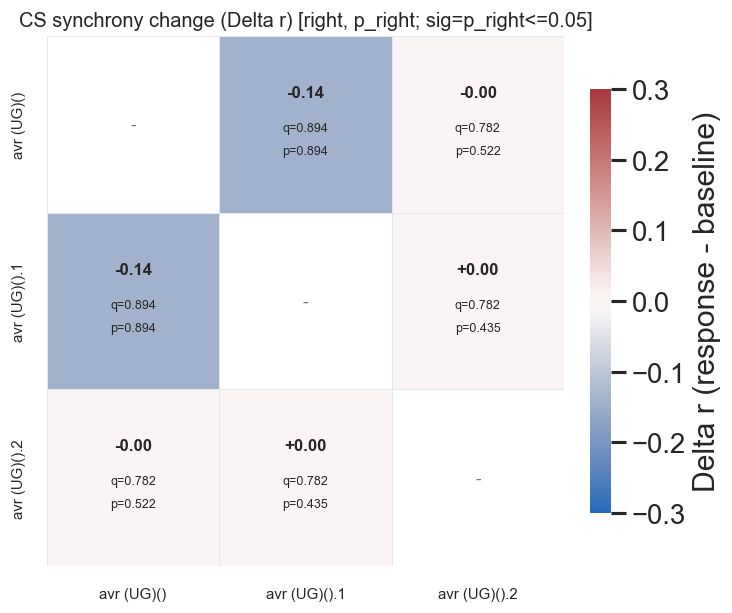


CS: no pairs reached p_right <= 0.05


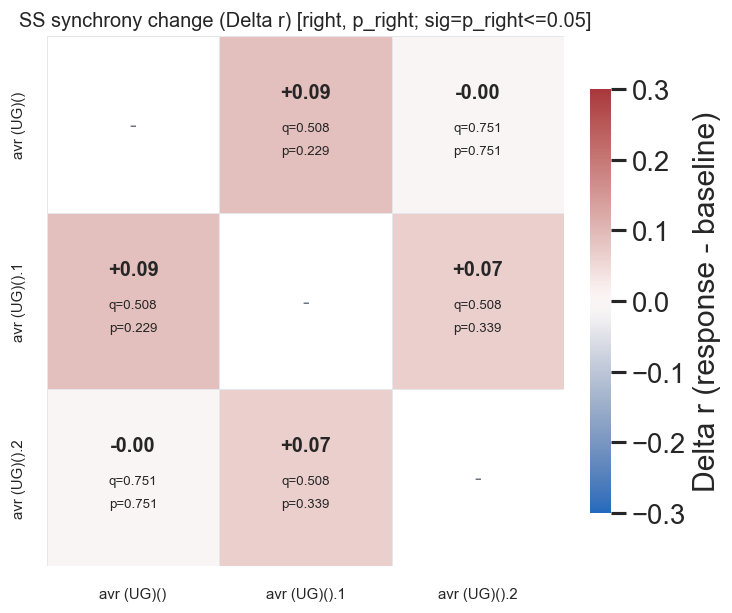


SS: no pairs reached p_right <= 0.05

SYNC_CHANGE_MATRIX_FDR_DONE


In [29]:
# -- Final synchrony change matrix with configurable significance overlay --
# Builds delta-r matrices (response - baseline) and reports significance
# using either p_selected or q_bh_fdr, controlled by SIGNIFICANCE_REPORT_CONFIG.


def _resolve_sig_metric(p_label):
    cfg = globals().get('SIGNIFICANCE_REPORT_CONFIG', {})
    metric_raw = str(cfg.get('metric', 'p')).strip().lower()
    alpha = float(cfg.get('alpha', 0.05))
    if not np.isfinite(alpha):
        alpha = 0.05
    alpha = max(0.0, min(alpha, 1.0))

    if metric_raw in {'q', 'fdr', 'bh', 'q_bh_fdr'}:
        return 'q_bh_fdr', 'q_bh_fdr', alpha
    return 'p_selected', p_label, alpha


def _plot_sync_change_matrix_from_pair_fdr(pair_df):
    if pair_df is None or pair_df.empty:
        print('pair_fdr_df is missing or empty. Run the pair-level FDR cell first.')
        return

    for stype in sorted(pair_df['spike_type'].unique()):
        sub = pair_df[pair_df['spike_type'] == stype].copy()

        tail_mode = str(sub['tail_mode'].iloc[0]) if 'tail_mode' in sub.columns and len(sub) else 'right'
        p_label = str(sub['p_selected_label'].iloc[0]) if 'p_selected_label' in sub.columns and len(sub) else 'p_selected'

        if 'p_selected' in sub.columns:
            p_col = 'p_selected'
        else:
            p_col = 'p_right' if tail_mode == 'right' else ('p_left' if tail_mode == 'left' else 'p_two_sided')
            p_label = p_col
            if p_col in sub.columns:
                sub['p_selected'] = pd.to_numeric(sub[p_col], errors='coerce')

        sig_col, sig_label, sig_alpha = _resolve_sig_metric(p_label)
        if sig_col not in sub.columns:
            sig_col, sig_label = 'q_bh_fdr', 'q_bh_fdr'

        # Build n_cells x n_cells matrices for delta_r, q-values, and selected p-values.
        delta_mat = np.full((n_cells, n_cells), np.nan)
        q_mat = np.full((n_cells, n_cells), np.nan)
        p_mat = np.full((n_cells, n_cells), np.nan)
        sig_mat = np.full((n_cells, n_cells), np.nan)

        for _, row in sub.iterrows():
            i, j = int(row['cell_i']), int(row['cell_j'])
            delta_mat[i, j] = row['delta_r_obs']
            delta_mat[j, i] = row['delta_r_obs']
            q_mat[i, j] = row['q_bh_fdr']
            q_mat[j, i] = row['q_bh_fdr']

            p_val = row[p_col] if p_col in row.index else np.nan
            p_mat[i, j] = p_val
            p_mat[j, i] = p_val

            s_val = row[sig_col] if sig_col in row.index else np.nan
            sig_mat[i, j] = s_val
            sig_mat[j, i] = s_val

        # Dynamic limits kept as fallback; global CORR_HEATMAP_SCALE wrapper can override.
        finite_vals = delta_mat[np.isfinite(delta_mat)]
        if finite_vals.size > 0:
            vabs = max(abs(np.nanmin(finite_vals)), abs(np.nanmax(finite_vals)), 0.01)
        else:
            vabs = 0.1

        fig, ax = plt.subplots(
            figsize=(max(6, n_cells * 1.4), max(5, n_cells * 1.2)),
            constrained_layout=True,
        )
        sns.heatmap(
            delta_mat,
            ax=ax,
            annot=False,
            fmt='',
            cmap='vlag',
            center=0,
            vmin=-vabs,
            vmax=vabs,
            xticklabels=cell_names,
            yticklabels=cell_names,
            linewidths=0.5,
            linecolor='#E5E7EB',
            cbar_kws={'label': 'Delta r (response - baseline)', 'shrink': 0.8},
        )

        # Custom text overlays so delta-r and significance are readable.
        is_ss = str(stype).upper() == 'SS'
        dr_font = 12 if is_ss else 10
        q_font = 8 if is_ss else 7.5
        star_font = 16 if is_ss else 13

        for ci in range(n_cells):
            for cj in range(n_cells):
                x = cj + 0.5
                y = ci + 0.5

                if ci == cj:
                    ax.text(x, y, '-', ha='center', va='center', fontsize=dr_font, color='#6B7280')
                    continue

                dr = delta_mat[ci, cj]
                qv = q_mat[ci, cj]
                pv = p_mat[ci, cj]
                sv = sig_mat[ci, cj]

                if not np.isfinite(dr):
                    ax.text(x, y, 'n/a', ha='center', va='center', fontsize=q_font, color='#6B7280')
                    continue

                stars = ''
                if np.isfinite(sv):
                    if sv <= 0.001:
                        stars = '***'
                    elif sv <= 0.01:
                        stars = '**'
                    elif sv <= sig_alpha:
                        stars = '*'

                ax.text(x, y - 0.18, f'{dr:+.2f}', ha='center', va='center', fontsize=dr_font, fontweight='bold')
                if np.isfinite(qv):
                    ax.text(x, y + 0.02, f'q={qv:.3f}', ha='center', va='center', fontsize=q_font)
                if np.isfinite(pv):
                    ax.text(x, y + 0.15, f'p={pv:.3f}', ha='center', va='center', fontsize=q_font)
                if stars:
                    ax.text(x, y + 0.30, stars, ha='center', va='center', fontsize=star_font, fontweight='bold')

        ax.set_title(
            f'{stype} synchrony change (Delta r) '\
            f'[{tail_mode}, {p_label}; sig={sig_label}<={sig_alpha:g}]',
            fontsize=12,
        )
        ax.set_xlabel('')
        ax.set_ylabel('')

        _save_fig_svg(fig, f'sync_change_matrix_{stype}')
        plt.show()

        # Print significant pairs using selected reporting metric.
        sig = sub[np.isfinite(sub[sig_col]) & (sub[sig_col] <= sig_alpha)].sort_values(sig_col)
        if len(sig):
            print(f'\n{stype} significant pairs ({sig_label} <= {sig_alpha:g}):')
            for _, r in sig.iterrows():
                ci, cj = int(r['cell_i']), int(r['cell_j'])
                p_val = r[p_col] if p_col in r.index else np.nan
                sig_val = r[sig_col] if sig_col in r.index else np.nan
                print(
                    f'  {cell_names[ci]} <-> {cell_names[cj]}:  '
                    f'Delta r={r["delta_r_obs"]:+.4f}  {p_label}={p_val:.4f}  '
                    f'q={r["q_bh_fdr"]:.4f}  {sig_label}={sig_val:.4f}  z={r["z_like"]:.2f}'
                )
        else:
            print(f'\n{stype}: no pairs reached {sig_label} <= {sig_alpha:g}')

    print('\nSYNC_CHANGE_MATRIX_FDR_DONE')


_plot_sync_change_matrix_from_pair_fdr(pair_fdr_df)

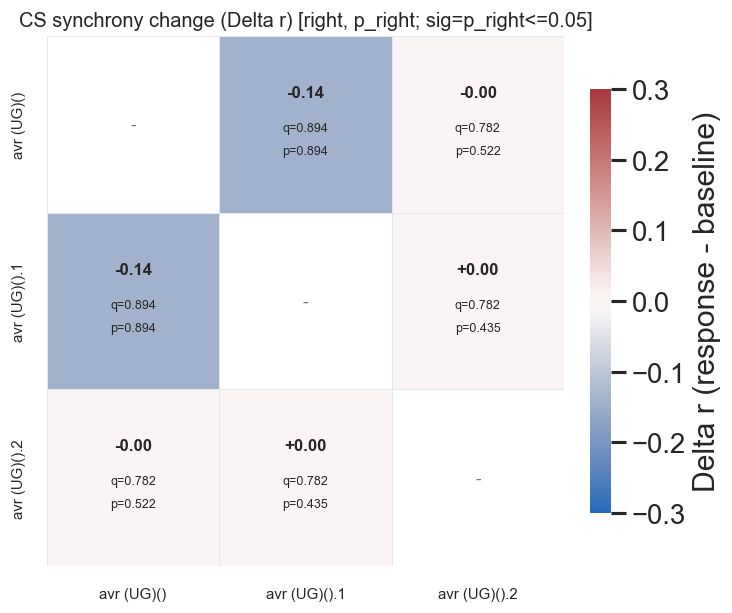


CS: no pairs reached p_right <= 0.05


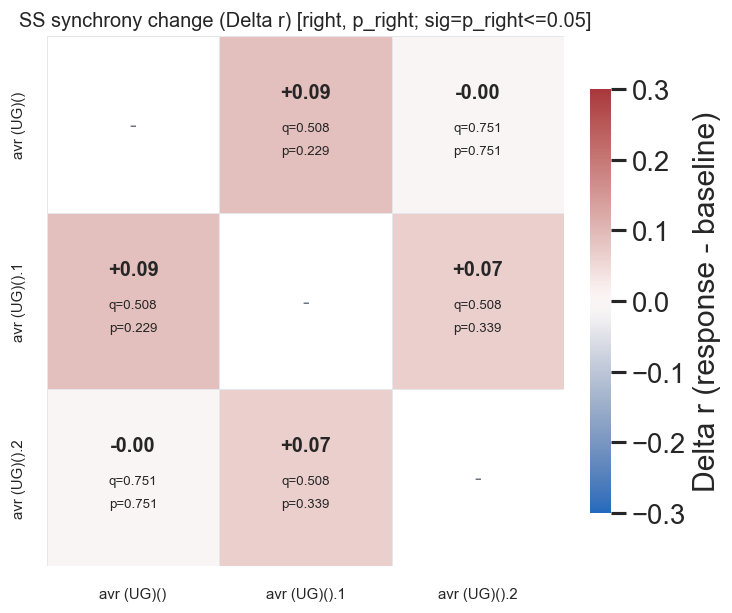


SS: no pairs reached p_right <= 0.05

SYNC_CHANGE_MATRIX_FDR_DONE


In [30]:
# Legacy compatibility cell: reuse the same matrix plotting logic/settings from the previous cell.

if '_plot_sync_change_matrix_from_pair_fdr' not in globals():
    print('Matrix helper is not defined. Run Cell 18 first.')
elif 'pair_fdr_df' not in globals() or pair_fdr_df.empty:
    print('pair_fdr_df is missing or empty. Run the pair-level FDR cell first.')
else:
    _plot_sync_change_matrix_from_pair_fdr(pair_fdr_df)

In [18]:
# Diagnostic: why some CS pair correlations are NaN, and does enlarging windows help?
print('CS correlation diagnositic: finite-support checks by pair and window')

def _windowed_pair_corr_debug(times_a, times_b, event_time_ms, window_rel_ms, bin_ms):
    w0, w1 = float(window_rel_ms[0]), float(window_rel_ms[1])
    t0 = float(event_time_ms) + w0
    t1 = float(event_time_ms) + w1
    if t1 <= t0:
        return np.nan, 'bad_window'

    edges = np.arange(t0, t1 + float(bin_ms), float(bin_ms))
    if len(edges) < 3:
        return np.nan, 'too_few_bins'

    a_counts, _ = np.histogram(np.asarray(times_a, dtype=float), bins=edges)
    b_counts, _ = np.histogram(np.asarray(times_b, dtype=float), bins=edges)

    if np.std(a_counts) == 0:
        if np.sum(a_counts) == 0:
            return np.nan, 'a_no_spikes'
        return np.nan, 'a_zero_variance'
    if np.std(b_counts) == 0:
        if np.sum(b_counts) == 0:
            return np.nan, 'b_no_spikes'
        return np.nan, 'b_zero_variance'

    return float(np.corrcoef(a_counts, b_counts)[0, 1]), 'ok'


def _pair_window_support_table(sessions_local, spike_key, baseline_w, response_w, event_time_ms, bin_ms):
    rows = []
    for i, j in combinations(range(n_cells), 2):
        base_ok = 0
        resp_ok = 0
        delta_ok = 0
        base_reasons = {}
        resp_reasons = {}

        for s in sessions_local:
            rb, rb_reason = _windowed_pair_corr_debug(
                s[spike_key][i], s[spike_key][j], event_time_ms, baseline_w, bin_ms
            )
            rr, rr_reason = _windowed_pair_corr_debug(
                s[spike_key][i], s[spike_key][j], event_time_ms, response_w, bin_ms
            )

            base_reasons[rb_reason] = base_reasons.get(rb_reason, 0) + 1
            resp_reasons[rr_reason] = resp_reasons.get(rr_reason, 0) + 1

            if np.isfinite(rb):
                base_ok += 1
            if np.isfinite(rr):
                resp_ok += 1
            if np.isfinite(rb) and np.isfinite(rr):
                delta_ok += 1

        rows.append({
            'pair': f'{cell_names[i]} vs {cell_names[j]}',
            'pair_idx': f'({i},{j})',
            'baseline_ok_sessions': base_ok,
            'response_ok_sessions': resp_ok,
            'delta_ok_sessions': delta_ok,
            'baseline_reasons': base_reasons,
            'response_reasons': resp_reasons,
        })

    return pd.DataFrame(rows)

# Current config check
cs_bin = float(EVENT_CONFIG['cs_sync_bin_ms'])
cs_base = tuple(EVENT_CONFIG['cs_sync_baseline_ms'])
cs_resp = tuple(EVENT_CONFIG['cs_sync_response_ms'])

print(f'Current CS config: baseline={cs_base}, response={cs_resp}, bin_ms={cs_bin}')
current_tbl = _pair_window_support_table(
    sessions_local=sessions,
    spike_key='spike_times_cs',
    baseline_w=cs_base,
    response_w=cs_resp,
    event_time_ms=float(EVENT_CONFIG['event_time_ms']),
    bin_ms=cs_bin,
)
display(current_tbl[['pair', 'pair_idx', 'baseline_ok_sessions', 'response_ok_sessions', 'delta_ok_sessions', 'baseline_reasons', 'response_reasons']])

# Window sweep for CS support
window_candidates = [
    ((-500.0, -100.0), (0.0, 500.0), 'legacy_500ms'),
    ((-800.0, 0.0), (0.0, 800.0), 'current_800ms'),
    ((-1000.0, 0.0), (0.0, 1000.0), 'wider_1000ms'),
    ((-1200.0, 0.0), (0.0, 1200.0), 'wider_1200ms'),
]

sweep_rows = []
for b_w, r_w, tag in window_candidates:
    tbl = _pair_window_support_table(
        sessions_local=sessions,
        spike_key='spike_times_cs',
        baseline_w=b_w,
        response_w=r_w,
        event_time_ms=float(EVENT_CONFIG['event_time_ms']),
        bin_ms=cs_bin,
    )
    for row in tbl.itertuples(index=False):
        sweep_rows.append({
            'window_tag': tag,
            'baseline_w': b_w,
            'response_w': r_w,
            'pair': row.pair,
            'pair_idx': row.pair_idx,
            'delta_ok_sessions': int(row.delta_ok_sessions),
            'baseline_ok_sessions': int(row.baseline_ok_sessions),
            'response_ok_sessions': int(row.response_ok_sessions),
        })

sweep_df = pd.DataFrame(sweep_rows)
print('\nCS window support sweep (higher delta_ok_sessions is better):')
display(sweep_df.sort_values(['pair_idx', 'delta_ok_sessions', 'window_tag'], ascending=[True, False, True]))

CS correlation diagnositic: finite-support checks by pair and window
Current CS config: baseline=(-1200.0, 0.0), response=(0.0, 1200.0), bin_ms=25.0


,pair,pair_idx,baseline_ok_sessions,response_ok_sessions,delta_ok_sessions,baseline_reasons,response_reasons
0,avr (UG)() vs avr (UG)().1,"(0,1)",6,3,3,"{'ok': 6, 'b_no_spikes': 1}","{'a_no_spikes': 4, 'ok': 3}"
1,avr (UG)() vs avr (UG)().2,"(0,2)",6,2,2,"{'ok': 6, 'b_no_spikes': 1}","{'a_no_spikes': 4, 'ok': 2, 'b_no_spikes': 1}"
2,avr (UG)().1 vs avr (UG)().2,"(1,2)",5,3,3,"{'ok': 5, 'b_no_spikes': 1, 'a_no_spikes': 1}","{'a_no_spikes': 1, 'ok': 3, 'b_no_spikes': 3}"



CS window support sweep (higher delta_ok_sessions is better):


,window_tag,baseline_w,response_w,pair,pair_idx,delta_ok_sessions,baseline_ok_sessions,response_ok_sessions
9,wider_1200ms,"(-1200.0, 0.0)","(0.0, 1200.0)",avr (UG)() vs avr (UG)().1,"(0,1)",3,6,3
3,current_800ms,"(-800.0, 0.0)","(0.0, 800.0)",avr (UG)() vs avr (UG)().1,"(0,1)",1,5,2
6,wider_1000ms,"(-1000.0, 0.0)","(0.0, 1000.0)",avr (UG)() vs avr (UG)().1,"(0,1)",1,5,2
0,legacy_500ms,"(-500.0, -100.0)","(0.0, 500.0)",avr (UG)() vs avr (UG)().1,"(0,1)",0,1,2
10,wider_1200ms,"(-1200.0, 0.0)","(0.0, 1200.0)",avr (UG)() vs avr (UG)().2,"(0,2)",2,6,2
4,current_800ms,"(-800.0, 0.0)","(0.0, 800.0)",avr (UG)() vs avr (UG)().2,"(0,2)",1,4,1
7,wider_1000ms,"(-1000.0, 0.0)","(0.0, 1000.0)",avr (UG)() vs avr (UG)().2,"(0,2)",1,4,1
1,legacy_500ms,"(-500.0, -100.0)","(0.0, 500.0)",avr (UG)() vs avr (UG)().2,"(0,2)",0,1,1
11,wider_1200ms,"(-1200.0, 0.0)","(0.0, 1200.0)",avr (UG)().1 vs avr (UG)().2,"(1,2)",3,5,3
5,current_800ms,"(-800.0, 0.0)","(0.0, 800.0)",avr (UG)().1 vs avr (UG)().2,"(1,2)",2,4,2


In [19]:
# Global correlation-heatmap color scaling (user setting)
# Default fixed range: [-0.3, +0.3] for all correlation matrices using cmap='vlag'.
CORR_HEATMAP_SCALE = {
    'enabled': True,
    'vmin': -0.3,
    'vmax': 0.3,
    'center': 0.0,
    'apply_to_vlag_only': True,
}

# Correlation-matrix style tweaks.
# Reduce cell-name tick label size in matrix heatmaps.
CORR_MATRIX_STYLE = {
    'cell_name_fontsize': 9,
}

# Pair-level significance tail mode for inference p-values.
# Options: 'right' (default), 'left', 'two-sided'.
SIGNIFICANCE_TEST_CONFIG = {
    'tail': 'right',
}

# Reporting metric for significance overlays in summary/matrix outputs.
# metric options: 'p' (uses p_selected from current tail mode) or 'q' (BH-FDR q-value)
SIGNIFICANCE_REPORT_CONFIG = {
    'metric': 'p',
    'alpha': 0.05,
}

# Install a safe seaborn heatmap wrapper once; rerunning this cell updates settings only.
if not hasattr(sns, '_heatmap_original'):
    sns._heatmap_original = sns.heatmap


def _heatmap_with_corr_scale(*args, **kwargs):
    cfg = globals().get('CORR_HEATMAP_SCALE', {})
    use_map = True
    if bool(cfg.get('enabled', True)):
        if bool(cfg.get('apply_to_vlag_only', True)):
            use_map = (kwargs.get('cmap', None) == 'vlag')
        if use_map:
            kwargs['vmin'] = float(cfg.get('vmin', -0.3))
            kwargs['vmax'] = float(cfg.get('vmax', 0.3))
            kwargs['center'] = float(cfg.get('center', 0.0))

    ax = sns._heatmap_original(*args, **kwargs)

    if use_map:
        label_fs = globals().get('CORR_MATRIX_STYLE', {}).get('cell_name_fontsize', None)
        if label_fs is not None:
            ax.tick_params(axis='x', labelsize=float(label_fs))
            ax.tick_params(axis='y', labelsize=float(label_fs))

    return ax


sns.heatmap = _heatmap_with_corr_scale
print(
    f"CORR_HEATMAP_SCALE active: enabled={CORR_HEATMAP_SCALE['enabled']}, "
    f"range=[{CORR_HEATMAP_SCALE['vmin']}, {CORR_HEATMAP_SCALE['vmax']}]"
)
print(f"CORR_MATRIX_STYLE cell_name_fontsize: {CORR_MATRIX_STYLE['cell_name_fontsize']}")
print(f"SIGNIFICANCE_TEST_CONFIG tail mode: {SIGNIFICANCE_TEST_CONFIG['tail']}")
print(
    f"SIGNIFICANCE_REPORT_CONFIG: metric={SIGNIFICANCE_REPORT_CONFIG['metric']}, "
    f"alpha={SIGNIFICANCE_REPORT_CONFIG['alpha']}"
)

CORR_HEATMAP_SCALE active: enabled=True, range=[-0.3, 0.3]
CORR_MATRIX_STYLE cell_name_fontsize: 9
SIGNIFICANCE_TEST_CONFIG tail mode: right
SIGNIFICANCE_REPORT_CONFIG: metric=p, alpha=0.05
